# Experimental Comparison of Full BERT Fine-Tuning vs LoRA for Sentiment Analysis

## 01. Project Introduction

This notebook performs a **controlled experimental comparison** between:

1. **Full-parameter fine-tuning** of `bert-base-uncased`
2. **LoRA (Low-Rank Adaptation) fine-tuning** of the same `bert-base-uncased` checkpoint

on the **IMDb Movie Reviews** sentiment classification dataset (binary: negative=0, positive=1).

**Why this matters:** LoRA is often claimed to be a cheaper alternative to full fine-tuning.
This notebook does not assume that claim — it measures it, using identical data, identical
hyperparameters, and identical evaluation protocol for both approaches, so that any
observed difference in performance, memory, time, or storage can be attributed to the
*method* rather than to inconsistent experimental conditions.

**What you'll get from running this top-to-bottom in Google Colab:**
- Two trained models (Full BERT, LoRA BERT) under a fair comparison protocol
- Predictive performance metrics (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC)
- Trainable/total parameter counts and reduction percentage
- Peak GPU memory usage during training
- Training time and inference time
- Model storage size on disk
- Error analysis, prediction agreement, and explainability comparison
- A final auto-generated research conclusion based only on measured results

## 02. Research Question

**How does parameter-efficient LoRA fine-tuning compare with full-parameter BERT
fine-tuning for sentiment classification, when both approaches use the same dataset,
preprocessing, data splits, tokenizer, batch size, learning rate, number of epochs,
evaluation procedure, and random seed?**

This experiment isolates the training strategy (full fine-tuning vs. frozen-backbone +
LoRA adapters) as the single independent variable, and measures its effect on:

- Predictive performance
- Trainable / total parameters
- GPU memory consumption
- Training time
- Inference time
- Convergence behavior
- Model storage size
- Computational efficiency (performance per trainable parameter)

## 03. Experimental Hypothesis

**H1 —** LoRA should achieve competitive sentiment classification performance while
substantially reducing the number of trainable parameters.

**H2 —** LoRA should require substantially fewer trainable parameters and produce a
smaller trainable checkpoint (adapter-only) than full fine-tuning.

**H3 —** LoRA may reduce peak GPU memory, although the savings may be smaller than the
trainable-parameter reduction, because activations and the frozen base model still
consume memory regardless of how many parameters are trainable.

**H4 —** Full fine-tuning may achieve slightly different (not necessarily better)
predictive performance, because all BERT parameters — not just low-rank adapters — are
free to adapt to the task.

These hypotheses are evaluated against the actual measured results in **Section 44**
and the final conclusion in **Section 47**. No hypothesis is assumed to be true in
advance.

## 04. Environment Setup — Installation

We install only the packages required for this experiment. If a package is already
present in the Colab runtime, `pip` will skip reinstalling it.

**Packages:** `transformers`, `datasets`, `peft`, `accelerate`, `evaluate`,
`scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `captum` (for
Integrated-Gradients explainability).

**Expected output:** pip install logs, followed by a printed version table in the next
section.

In [1]:

!pip uninstall -y -q transformers datasets peft accelerate tokenizers 2>/dev/null

!pip install -q -U \
    "transformers==4.44.2" \
    "datasets==2.21.0" \
    "peft==0.12.0" \
    "accelerate==0.34.2" \
    "tokenizers==0.19.1" \
    "evaluate==0.4.2" \
    "scikit-learn" "pandas" "numpy<2.0" "matplotlib" "seaborn" "captum"

print("Install complete.")


Install complete.


## 05. Imports

Standard scientific-Python, PyTorch, Hugging Face, and PEFT imports. We also import
`captum` for explainability (Section 39) and set matplotlib/seaborn styling once for
consistent plots across the notebook.

**Why:** centralizing imports makes the notebook easier to audit and re-run; nothing
here is training-specific yet.

In [2]:

import os, sys, time, json, math, random, copy, platform

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader

    import transformers
    from transformers import (
        AutoTokenizer,
        BertForSequenceClassification,
        get_linear_schedule_with_warmup,
    )

    import datasets
    from datasets import load_dataset

    import peft
    from peft import LoraConfig, get_peft_model, TaskType

    from sklearn.metrics import (
        accuracy_score, precision_recall_fscore_support,
        roc_auc_score, average_precision_score, confusion_matrix,
        roc_curve, precision_recall_curve
    )
    from sklearn.model_selection import train_test_split

except ImportError as e:
    print("=" * 70)
    print("IMPORT FAILED:", e)
    print("=" * 70)
    print("This almost always means the runtime was not restarted after the")
    print("installation cell ran. Fix:")
    print("  1. Runtime > Restart session (do NOT just re-run the install cell)")
    print("  2. Re-run every cell from the top of the notebook, in order")
    print("=" * 70)
    raise

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Imports OK")
print(f"transformers: {transformers.__version__}")
print(f"datasets:     {datasets.__version__}")
print(f"peft:         {peft.__version__}")
print(f"torch:        {torch.__version__}")


Imports OK
transformers: 4.44.2
datasets:     2.21.0
peft:         0.12.0
torch:        2.11.0+cu128


## 05b. Environment Report

Prints Python / library versions and detects CUDA vs CPU. The notebook is written to
run on either device, but GPU is strongly recommended — full fine-tuning of BERT-base
on CPU will be very slow.

**Expected output:** a version/device summary block. If no GPU is detected, a warning
is printed and training will proceed on CPU (correct, but slow).

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)
print(f"Python version:        {platform.python_version()}")
print(f"PyTorch version:       {torch.__version__}")
print(f"Transformers version:  {transformers.__version__}")
print(f"PEFT version:          {peft.__version__}")
print(f"Datasets version:      {datasets.__version__}")
print(f"CUDA available:        {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:                   {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU memory:            {total_mem:.2f} GB")
else:
    print("GPU:                   None")
    print("GPU memory:            N/A")
print(f"Device:                {device}")
print("=" * 60)

if not torch.cuda.is_available():
    print("WARNING: No CUDA GPU detected. Training will run on CPU and will be "
          "substantially slower. In Colab, use Runtime > Change runtime type > GPU.")

ENVIRONMENT
Python version:        3.12.13
PyTorch version:       2.11.0+cu128
Transformers version:  4.44.2
PEFT version:          0.12.0
Datasets version:      2.21.0
CUDA available:        True
GPU:                   Tesla T4
GPU memory:            14.56 GB
Device:                cuda


## 06. Configuration

A **single central configuration dictionary** drives both experiments. This is the
mechanism that guarantees fairness: Full BERT and LoRA read their hyperparameters from
the *same* `CONFIG` object, so it is structurally impossible to accidentally give one
experiment a different learning rate, batch size, or epoch count than the other.

The only LoRA-specific keys (`lora_r`, `lora_alpha`, `lora_dropout`) are inert for the
Full BERT experiment — they are simply unused in that code path.

**Expected output:** the printed configuration dictionary, which should be referred
back to whenever you want to confirm both experiments used identical settings.

In [4]:
CONFIG = {
    "seed": 42,
    "model_name": "bert-base-uncased",
    "max_length": 256,
    "batch_size": 16,
    "eval_batch_size": 32,
    "epochs": 3,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "gradient_accumulation_steps": 1,
    "num_labels": 2,
    "lora_r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.1,
    "lora_target_modules": ["query", "value"],
    "early_stopping_patience": 2,
    # Practical subsampling so the notebook is runnable end-to-end in a single Colab
    # session. Set to None to use the FULL IMDb train/test sets (25,000 / 25,000).
    # Both experiments always use the identical subsample — this is a runtime
    # convenience, not a source of unfairness between Full BERT and LoRA.
    "train_subsample": 4000,
    "test_subsample": 2000,
    "run_multi_seed": False,   # Section 45 — off by default (compute cost)
    "output_dir": "outputs",
}

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
for k, v in CONFIG.items():
    print(f"{k:30s}: {v}")
print("=" * 60)
print()
print("NOTE: 'train_subsample' / 'test_subsample' limit dataset size purely for "
      "Colab runtime feasibility. Both Full BERT and LoRA ALWAYS see the identical "
      "subsample (same indices, same seed) -- see Section 11. Set both to None for "
      "a full-scale run if you have sufficient GPU time.")

CONFIGURATION
seed                          : 42
model_name                    : bert-base-uncased
max_length                    : 256
batch_size                    : 16
eval_batch_size               : 32
epochs                        : 3
learning_rate                 : 2e-05
weight_decay                  : 0.01
warmup_ratio                  : 0.1
gradient_accumulation_steps   : 1
num_labels                    : 2
lora_r                        : 8
lora_alpha                    : 16
lora_dropout                  : 0.1
lora_target_modules           : ['query', 'value']
early_stopping_patience       : 2
train_subsample               : 4000
test_subsample                : 2000
run_multi_seed                : False
output_dir                    : outputs

NOTE: 'train_subsample' / 'test_subsample' limit dataset size purely for Colab runtime feasibility. Both Full BERT and LoRA ALWAYS see the identical subsample (same indices, same seed) -- see Section 11. Set both to None for a full-scale r

## 07. Reproducibility

We fix the random seed across Python's `random`, NumPy, and PyTorch (CPU + CUDA), and
enable deterministic cuDNN behavior where possible. This does not guarantee bit-for-bit
determinism across different hardware/driver versions, but it removes randomness as a
confound between the two experiments run in this same notebook session.

**Expected output:** confirmation that the seed and deterministic flags were applied.

In [5]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

print(f"Random seed:        {CONFIG['seed']}")
print(f"Deterministic mode: {torch.backends.cudnn.deterministic}")

Random seed:        42
Deterministic mode: True


## Output Directory Setup

Creates the directory tree used throughout the notebook to store models, plots,
predictions, explainability artifacts, error analyses, tables, logs, and reports —
matching the structure required for a genuine, auditable experiment record.

In [6]:
OUT = CONFIG["output_dir"]
subdirs = [
    "models/full_bert", "models/lora", "plots", "predictions",
    "explainability", "errors", "tables", "logs", "reports",
]
for d in subdirs:
    os.makedirs(os.path.join(OUT, d), exist_ok=True)

print("Created output directories under:", OUT)
for d in subdirs:
    print(" -", os.path.join(OUT, d))

Created output directories under: outputs
 - outputs/models/full_bert
 - outputs/models/lora
 - outputs/plots
 - outputs/predictions
 - outputs/explainability
 - outputs/errors
 - outputs/tables
 - outputs/logs
 - outputs/reports


## 08. Dataset Loading

Loads the standard **IMDb** dataset (`imdb` on the Hugging Face Hub): 25,000 train and
25,000 test movie reviews, binary-labeled (0 = negative, 1 = positive), balanced 50/50
in both splits.

**Why IMDb:** it is the standard sentiment-classification benchmark, well suited to a
BERT fine-tuning comparison, and small enough to fine-tune within a single Colab
session while still being a realistic NLP task.

Both experiments (Full BERT and LoRA) will reuse this exact loaded dataset — the
dataset is loaded **once**, in this cell, and never reloaded independently per
experiment.

In [7]:
raw_datasets = load_dataset("imdb")

print("Dataset name:      imdb")
print("Training samples: ", len(raw_datasets["train"]))
print("Test samples:     ", len(raw_datasets["test"]))
print("Classes:           {0: 'negative', 1: 'positive'}")

train_labels = np.array(raw_datasets["train"]["label"])
test_labels = np.array(raw_datasets["test"]["label"])
print("Class distribution (train):", dict(zip(*np.unique(train_labels, return_counts=True))))
print("Class distribution (test): ", dict(zip(*np.unique(test_labels, return_counts=True))))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset name:      imdb
Training samples:  25000
Test samples:      25000
Classes:           {0: 'negative', 1: 'positive'}
Class distribution (train): {0: 12500, 1: 12500}
Class distribution (test):  {0: 12500, 1: 12500}


## 09-10. Dataset Inspection & Exploratory Data Analysis

We check basic data-quality issues (missing values, empty reviews, duplicate reviews,
duplicate text+label pairs) and the distribution of review lengths (in whitespace
tokens, as a proxy before subword tokenization). This determines whether `max_length =
256` (Section 06 config) is a reasonable truncation point, and confirms the dataset is
clean enough to use as-is.

**Expected output:** printed data-quality counts plus three saved plots:
class distribution, review-length histogram, review-length boxplot.

In [8]:
train_df = pd.DataFrame({"text": raw_datasets["train"]["text"], "label": raw_datasets["train"]["label"]})
test_df = pd.DataFrame({"text": raw_datasets["test"]["text"], "label": raw_datasets["test"]["label"]})

def data_quality_report(df, name):
    n_missing = df["text"].isna().sum()
    n_empty = (df["text"].str.strip() == "").sum()
    n_dup_text = df["text"].duplicated().sum()
    n_dup_pair = df.duplicated(subset=["text", "label"]).sum()
    print(f"--- {name} ---")
    print(f"Missing values:               {n_missing}")
    print(f"Empty reviews:                {n_empty}")
    print(f"Duplicate reviews (text):     {n_dup_text}")
    print(f"Duplicate text+label pairs:   {n_dup_pair}")
    print()

data_quality_report(train_df, "TRAIN")
data_quality_report(test_df, "TEST")

train_df["word_count"] = train_df["text"].str.split().apply(len)
print("Review length (words) -- train set:")
print(train_df["word_count"].describe())

--- TRAIN ---
Missing values:               0
Empty reviews:                0
Duplicate reviews (text):     96
Duplicate text+label pairs:   96

--- TEST ---
Missing values:               0
Empty reviews:                0
Duplicate reviews (text):     199
Duplicate text+label pairs:   199

Review length (words) -- train set:
count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64


/tmp/ipykernel_2900/2216057826.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Negative", "Positive"])


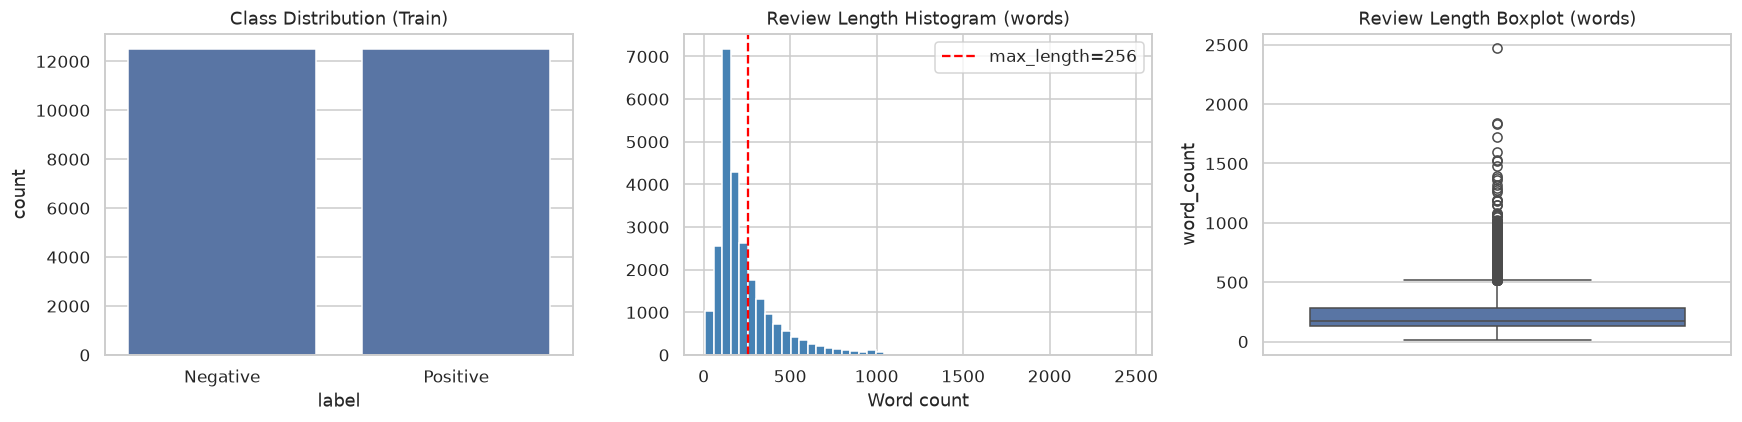

Saved: outputs/plots/dataset_eda.png

NOTE: max_length=256 subword tokens will truncate the long tail of reviews. This truncation is IDENTICAL for both experiments since they share the same tokenizer and max_length.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x="label", data=train_df, ax=axes[0])
axes[0].set_title("Class Distribution (Train)")
axes[0].set_xticklabels(["Negative", "Positive"])

axes[1].hist(train_df["word_count"], bins=50, color="steelblue")
axes[1].axvline(CONFIG["max_length"], color="red", linestyle="--", label=f'max_length={CONFIG["max_length"]}')
axes[1].set_title("Review Length Histogram (words)")
axes[1].set_xlabel("Word count")
axes[1].legend()

sns.boxplot(y=train_df["word_count"], ax=axes[2])
axes[2].set_title("Review Length Boxplot (words)")

plt.tight_layout()
plt.savefig(f"{OUT}/plots/dataset_eda.png")
plt.show()

print(f"Saved: {OUT}/plots/dataset_eda.png")
print()
print(f"NOTE: max_length={CONFIG['max_length']} subword tokens will truncate the "
      f"long tail of reviews. This truncation is IDENTICAL for both experiments "
      f"since they share the same tokenizer and max_length.")

## 11. Train / Validation / Test Split

We create **one** reproducible split that both experiments will reuse:

- IMDb's original **train** split -> stratified **80% train / 20% validation**
- IMDb's original **test** split -> used **100%** as the untouched final test set

Stratification preserves the 50/50 class balance in each subset. The resulting indices
are stored so that Full BERT and LoRA are guaranteed to train, validate, and test on
**exactly the same examples** — this is the single most important fairness control in
the whole notebook, since a different split would confound the comparison regardless of
how carefully hyperparameters are matched.

If `train_subsample` / `test_subsample` are set in `CONFIG` (Section 06), a stratified
subsample of that size is taken *before* splitting, purely to keep the notebook
runnable end-to-end on a single Colab GPU session; both experiments always see the
identical subsample.

In [10]:
set_seed(CONFIG["seed"])

full_train_df = train_df[["text", "label"]].copy()
full_test_df = test_df[["text", "label"]].copy()

if CONFIG["train_subsample"] is not None:
    full_train_df, _ = train_test_split(
        full_train_df, train_size=CONFIG["train_subsample"],
        stratify=full_train_df["label"], random_state=CONFIG["seed"]
    )
if CONFIG["test_subsample"] is not None:
    full_test_df, _ = train_test_split(
        full_test_df, train_size=CONFIG["test_subsample"],
        stratify=full_test_df["label"], random_state=CONFIG["seed"]
    )

train_split_df, val_split_df = train_test_split(
    full_train_df, test_size=0.2, stratify=full_train_df["label"],
    random_state=CONFIG["seed"]
)
test_split_df = full_test_df.reset_index(drop=True)
train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

def split_report(df, name):
    pos = int((df["label"] == 1).sum())
    neg = int((df["label"] == 0).sum())
    print(f"{name}:")
    print(f"  Positive: {pos}")
    print(f"  Negative: {neg}")
    print(f"  Total:    {len(df)}")
    print()

split_report(train_split_df, "Training")
split_report(val_split_df, "Validation")
split_report(test_split_df, "Testing")

print("These exact DataFrames (train_split_df, val_split_df, test_split_df) are "
      "reused, unmodified, by BOTH the Full BERT and LoRA experiments below.")

Training:
  Positive: 1600
  Negative: 1600
  Total:    3200

Validation:
  Positive: 400
  Negative: 400
  Total:    800

Testing:
  Positive: 1000
  Negative: 1000
  Total:    2000

These exact DataFrames (train_split_df, val_split_df, test_split_df) are reused, unmodified, by BOTH the Full BERT and LoRA experiments below.


## 12. Tokenization

We load the `bert-base-uncased` WordPiece tokenizer once and apply it identically to
train/val/test with `max_length=256`, padding to `max_length` and truncating longer
reviews.

**Special tokens:**
- `[CLS]` — prepended to every sequence; its final hidden state is used by BERT's
  pooler / classification head as the sequence-level representation.
- `[SEP]` — marks the end of a sequence (or separates sentence pairs; unused here
  beyond a single trailing `[SEP]`).
- `[PAD]` — padding token added so all sequences in a batch share the same length;
  masked out via `attention_mask` so it contributes nothing to attention.
- `[UNK]` — used for tokens/subwords the WordPiece vocabulary can't represent (rare
  for English text).

Both experiments use this **same tokenizer instance and same `max_length`** — a
required fairness condition (Rule 2 / Rule 3).

In [11]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

def tokenize_df(df):
    enc = tokenizer(
        list(df["text"]),
        padding="max_length",
        truncation=True,
        max_length=CONFIG["max_length"],
        return_tensors="pt",
    )
    enc["labels"] = torch.tensor(df["label"].values, dtype=torch.long)
    return enc

train_enc = tokenize_df(train_split_df)
val_enc = tokenize_df(val_split_df)
test_enc = tokenize_df(test_split_df)

example_idx = 0
example_text = train_split_df.iloc[example_idx]["text"]
example_ids = train_enc["input_ids"][example_idx]
example_tokens = tokenizer.convert_ids_to_tokens(example_ids)

print("Original text (truncated for display):")
print(example_text[:200], "...")
print()
print("Tokens (first 20):    ", example_tokens[:20])
print("Token IDs (first 20): ", example_ids[:20].tolist())
print("Attention mask (first 20):", train_enc['attention_mask'][example_idx][:20].tolist())
print("Token count (incl. padding):", len(example_ids))
print("Non-padding token count:", int(train_enc['attention_mask'][example_idx].sum()))

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Original text (truncated for display):
In what appears an attempt to mix drama and comedy, Manuel Gomez Pereira made this film, 'Things that make life worthwhile. "It is not an original discovery, by many voice you have (quite off the pitc ...

Tokens (first 20):     ['[CLS]', 'in', 'what', 'appears', 'an', 'attempt', 'to', 'mix', 'drama', 'and', 'comedy', ',', 'manuel', 'gomez', 'pereira', 'made', 'this', 'film', ',', "'"]
Token IDs (first 20):  [101, 1999, 2054, 3544, 2019, 3535, 2000, 4666, 3689, 1998, 4038, 1010, 7762, 12791, 23857, 2081, 2023, 2143, 1010, 1005]
Attention mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Token count (incl. padding): 256
Non-padding token count: 256


## 13. DataLoader Preparation

We wrap the tokenized tensors in a minimal `torch.utils.data.Dataset` and build
`DataLoader`s that both experiments will reuse. Training uses a **seeded generator**
for shuffling, so batch order is reproducible; validation and test loaders are not
shuffled (order doesn't affect their metrics).

**Expected shapes:** `[batch_size, 256]` for `input_ids` / `attention_mask`, and
`[batch_size]` for `labels`.

In [12]:
class IMDbTensorDataset(torch.utils.data.Dataset):
    def __init__(self, enc):
        self.enc = enc
    def __len__(self):
        return len(self.enc["labels"])
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.enc.items()}

train_ds = IMDbTensorDataset(train_enc)
val_ds = IMDbTensorDataset(val_enc)
test_ds = IMDbTensorDataset(test_enc)

g = torch.Generator()
g.manual_seed(CONFIG["seed"])

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, generator=g)
val_loader = DataLoader(val_ds, batch_size=CONFIG["eval_batch_size"], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CONFIG["eval_batch_size"], shuffle=False)

batch = next(iter(train_loader))
print("Input shape:          ", tuple(batch["input_ids"].shape))
print("Attention mask shape: ", tuple(batch["attention_mask"].shape))
print("Label shape:          ", tuple(batch["labels"].shape))
print(f"Expected: [batch_size, {CONFIG['max_length']}] for input_ids / attention_mask")

Input shape:           (16, 256)
Attention mask shape:  (16, 256)
Label shape:           (16,)
Expected: [batch_size, 256] for input_ids / attention_mask


## 14. BERT Architecture

We instantiate a reference `BertForSequenceClassification` (not yet trained) purely to
report its architecture and parameter counts before any experiment-specific
modification (full training vs. LoRA freezing) is applied.

**BERT-base architecture:** 12 Transformer encoder layers, 12 self-attention heads per
layer, hidden size 768, intermediate (feed-forward) size 3072, followed by a pooler and
a linear classification head mapping the pooled `[CLS]` representation to
`num_labels=2` logits.

In [13]:
reference_model = BertForSequenceClassification.from_pretrained(
    CONFIG["model_name"], num_labels=CONFIG["num_labels"]
)

total_params = sum(p.numel() for p in reference_model.parameters())
trainable_params = sum(p.numel() for p in reference_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {frozen_params:,}")
print()
print("Architecture summary:")
print(f"  Embeddings + Encoder (12 Transformer layers) + Pooler + Classifier")
print(f"  Encoder layers:      12")
print(f"  Attention heads:     12")
print(f"  Hidden size:         768")
print(f"  Intermediate size:   3072")
print()
print(reference_model.bert.encoder.layer[0])

del reference_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     109,483,778
Trainable parameters: 109,483,778
Frozen parameters:    0

Architecture summary:
  Embeddings + Encoder (12 Transformer layers) + Pooler + Classifier
  Encoder layers:      12
  Attention heads:     12
  Hidden size:         768
  Intermediate size:   3072

BertLayer(
  (attention): BertAttention(
    (self): BertSdpaSelfAttention(
      (query): Linear(in_features=768, out_features=768, bias=True)
      (key): Linear(in_features=768, out_features=768, bias=True)
      (value): Linear(in_features=768, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (output): BertSelfOutput(
      (dense): Linear(in_features=768, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (intermediate): BertIntermediate(
    (dense): Linear(in_features=768, out_features=3072, bias=True)
    (intermediate_act_fn): GELUActivation()
  

## 15. Common Training Configuration & Shared Train/Eval Code

Rather than writing two separate (and potentially subtly-different) training loops, we
write **one** generic `train_model()` function and **one** generic `evaluate_model()`
function. Both Experiment A (Full BERT) and Experiment B (LoRA) call these same
functions with the same `CONFIG` values — this is the strongest possible fairness
guarantee (Rules 4-8, 11-14): there is only one code path for training and evaluation
math, so it cannot silently diverge between experiments.

**Shared settings (from `CONFIG`):** AdamW optimizer, learning rate 2e-5, weight decay
0.01, linear scheduler with 10% warmup, batch size 16, 3 epochs, gradient accumulation
1, early stopping on validation F1 (patience configurable), checkpoint selection by
**best validation F1** — never by test performance (Rule 9, 10, 11, 12).

In [14]:
def compute_metrics(labels, preds, probs_pos):
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    try:
        roc_auc = roc_auc_score(labels, probs_pos)
    except ValueError:
        roc_auc = float("nan")
    try:
        pr_auc = average_precision_score(labels, probs_pos)
    except ValueError:
        pr_auc = float("nan")

    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    fpr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    fnr = fn / (fn + tp) if (fn + tp) > 0 else float("nan")

    return {
        "accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
        "roc_auc": roc_auc, "pr_auc": pr_auc, "specificity": specificity,
        "fpr": fpr, "fnr": fnr,
    }

def run_epoch(model, loader, optimizer=None, scheduler=None, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            loss = outputs.loss
            if train:
                loss = loss / CONFIG["gradient_accumulation_steps"]
                loss.backward()
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            total_loss += outputs.loss.item() * batch["labels"].size(0)
            probs = torch.softmax(outputs.logits, dim=-1)[:, 1].detach().cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            all_labels.extend(batch["labels"].cpu().numpy().tolist())
            all_preds.extend(preds.tolist())
            all_probs.extend(probs.tolist())

    avg_loss = total_loss / len(all_labels)
    metrics = compute_metrics(np.array(all_labels), np.array(all_preds), np.array(all_probs))
    metrics["loss"] = avg_loss
    return metrics

def train_model(model, name, train_loader, val_loader, config, memory_stats=None):
    """Generic training loop shared by BOTH Full BERT and LoRA experiments."""
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=config["learning_rate"], weight_decay=config["weight_decay"],
    )
    total_steps = len(train_loader) * config["epochs"]
    warmup_steps = int(total_steps * config["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = {"train": [], "val": []}
    best_f1 = -1.0
    best_state = None
    patience_counter = 0

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    t_start_total = time.time()
    epoch_times = []

    for epoch in range(1, config["epochs"] + 1):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.time()

        train_metrics = run_epoch(model, train_loader, optimizer, scheduler, train=True)
        val_metrics = run_epoch(model, val_loader, train=False)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        epoch_time = time.time() - t0
        epoch_times.append(epoch_time)

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        current_lr = scheduler.get_last_lr()[0]
        print(f"[{name}] Epoch {epoch}/{config['epochs']}")
        print(f"  Train  - loss: {train_metrics['loss']:.4f} acc: {train_metrics['accuracy']:.4f} "
              f"prec: {train_metrics['precision']:.4f} rec: {train_metrics['recall']:.4f} f1: {train_metrics['f1']:.4f}")
        print(f"  Val    - loss: {val_metrics['loss']:.4f} acc: {val_metrics['accuracy']:.4f} "
              f"prec: {val_metrics['precision']:.4f} rec: {val_metrics['recall']:.4f} f1: {val_metrics['f1']:.4f} "
              f"roc_auc: {val_metrics['roc_auc']:.4f} pr_auc: {val_metrics['pr_auc']:.4f}")
        print(f"  Learning rate: {current_lr:.2e} | Epoch time: {epoch_time:.1f}s")

        # Checkpoint selection: validation F1 only (Rule 9, 10, 11)
        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config["early_stopping_patience"]:
                print(f"  Early stopping triggered (no val F1 improvement for "
                      f"{config['early_stopping_patience']} epochs).")
                break
        print()

    total_time = time.time() - t_start_total
    print(f"Total elapsed time for {name}: {total_time:.1f}s "
          f"(best val F1: {best_f1:.4f})")

    if best_state is not None:
        model.load_state_dict(best_state)

    peak_allocated = torch.cuda.max_memory_allocated() / (1024**2) if torch.cuda.is_available() else 0.0
    peak_reserved = torch.cuda.max_memory_reserved() / (1024**2) if torch.cuda.is_available() else 0.0

    run_stats = {
        "history": history,
        "total_time_sec": total_time,
        "epoch_times_sec": epoch_times,
        "avg_epoch_time_sec": float(np.mean(epoch_times)),
        "avg_step_time_sec": float(np.mean(epoch_times)) / len(train_loader),
        "peak_allocated_mb": peak_allocated,
        "peak_reserved_mb": peak_reserved,
        "best_val_f1": best_f1,
    }
    return model, run_stats

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    return run_epoch(model, loader, train=False)

print("Shared train_model() / evaluate_model() / compute_metrics() defined. "
      "Both experiments below call these SAME functions.")

Shared train_model() / evaluate_model() / compute_metrics() defined. Both experiments below call these SAME functions.


## 16. Experiment A — Full-Parameter Fine-Tuning

We load a **fresh** `bert-base-uncased` checkpoint and leave **all** its parameters
trainable (this is the default state of a freshly-loaded Hugging Face model — we assert
it explicitly for clarity and to guard against silent misconfiguration).

**Expected trainable percentage: ~100%.**

In [15]:
set_seed(CONFIG["seed"])

full_model = BertForSequenceClassification.from_pretrained(
    CONFIG["model_name"], num_labels=CONFIG["num_labels"]
).to(device)

for p in full_model.parameters():
    p.requires_grad = True

total_p = sum(p.numel() for p in full_model.parameters())
trainable_p = sum(p.numel() for p in full_model.parameters() if p.requires_grad)
frozen_p = total_p - trainable_p
classifier_p = sum(p.numel() for p in full_model.classifier.parameters())

print("=" * 60)
print("FULL FINE-TUNING PARAMETER ANALYSIS")
print("=" * 60)
print(f"Total parameters:      {total_p:,}")
print(f"Trainable parameters:  {trainable_p:,}")
print(f"Frozen parameters:     {frozen_p:,}")
print(f"Trainable percentage:  {100 * trainable_p / total_p:.2f}%  (expected ~100%)")
print(f"Classification head parameters: {classifier_p:,}")
print("=" * 60)

full_bert_total_params = total_p
full_bert_trainable_params = trainable_p

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


FULL FINE-TUNING PARAMETER ANALYSIS
Total parameters:      109,483,778
Trainable parameters:  109,483,778
Frozen parameters:     0
Trainable percentage:  100.00%  (expected ~100%)
Classification head parameters: 1,538


## Full BERT — Memory Baseline (Before Training)

We reset CUDA peak-memory counters and record the allocated/reserved memory
immediately before training starts, giving a clean baseline for the peak-memory
comparison in Section 28.

In [16]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    alloc = torch.cuda.memory_allocated() / (1024**2)
    reserved = torch.cuda.memory_reserved() / (1024**2)
else:
    alloc = reserved = 0.0

print("=" * 60)
print("FULL BERT MEMORY -- BEFORE TRAINING")
print("=" * 60)
print(f"Allocated: {alloc:.1f} MB")
print(f"Reserved:  {reserved:.1f} MB")

FULL BERT MEMORY -- BEFORE TRAINING
Allocated: 418.7 MB
Reserved:  472.0 MB


## Full BERT — Training

Trains using the shared `train_model()` function defined in Section 15, with the exact
hyperparameters in `CONFIG`. Per-epoch training and validation metrics, learning rate,
and epoch time are printed live.

In [17]:
full_model, full_run_stats = train_model(
    full_model, "Full BERT", train_loader, val_loader, CONFIG
)

[Full BERT] Epoch 1/3
  Train  - loss: 0.4502 acc: 0.7747 prec: 0.7725 rec: 0.7788 f1: 0.7756
  Val    - loss: 0.2950 acc: 0.8762 prec: 0.8413 rec: 0.9275 f1: 0.8823 roc_auc: 0.9564 pr_auc: 0.9572
  Learning rate: 1.48e-05 | Epoch time: 142.3s

[Full BERT] Epoch 2/3
  Train  - loss: 0.2000 acc: 0.9250 prec: 0.9266 rec: 0.9231 f1: 0.9249
  Val    - loss: 0.3113 acc: 0.8862 prec: 0.8741 rec: 0.9025 f1: 0.8881 roc_auc: 0.9576 pr_auc: 0.9570
  Learning rate: 7.41e-06 | Epoch time: 151.6s

[Full BERT] Epoch 3/3
  Train  - loss: 0.0968 acc: 0.9716 prec: 0.9736 rec: 0.9694 f1: 0.9715
  Val    - loss: 0.3266 acc: 0.8900 prec: 0.8732 rec: 0.9125 f1: 0.8924 roc_auc: 0.9582 pr_auc: 0.9574
  Learning rate: 0.00e+00 | Epoch time: 154.6s

Total elapsed time for Full BERT: 448.6s (best val F1: 0.8924)


## 17. Full BERT — Training Curves

Plots training vs. validation loss, accuracy, precision, recall, F1, and the learning
rate schedule across epochs, saved to `outputs/plots/full_bert_training_curves.png`.

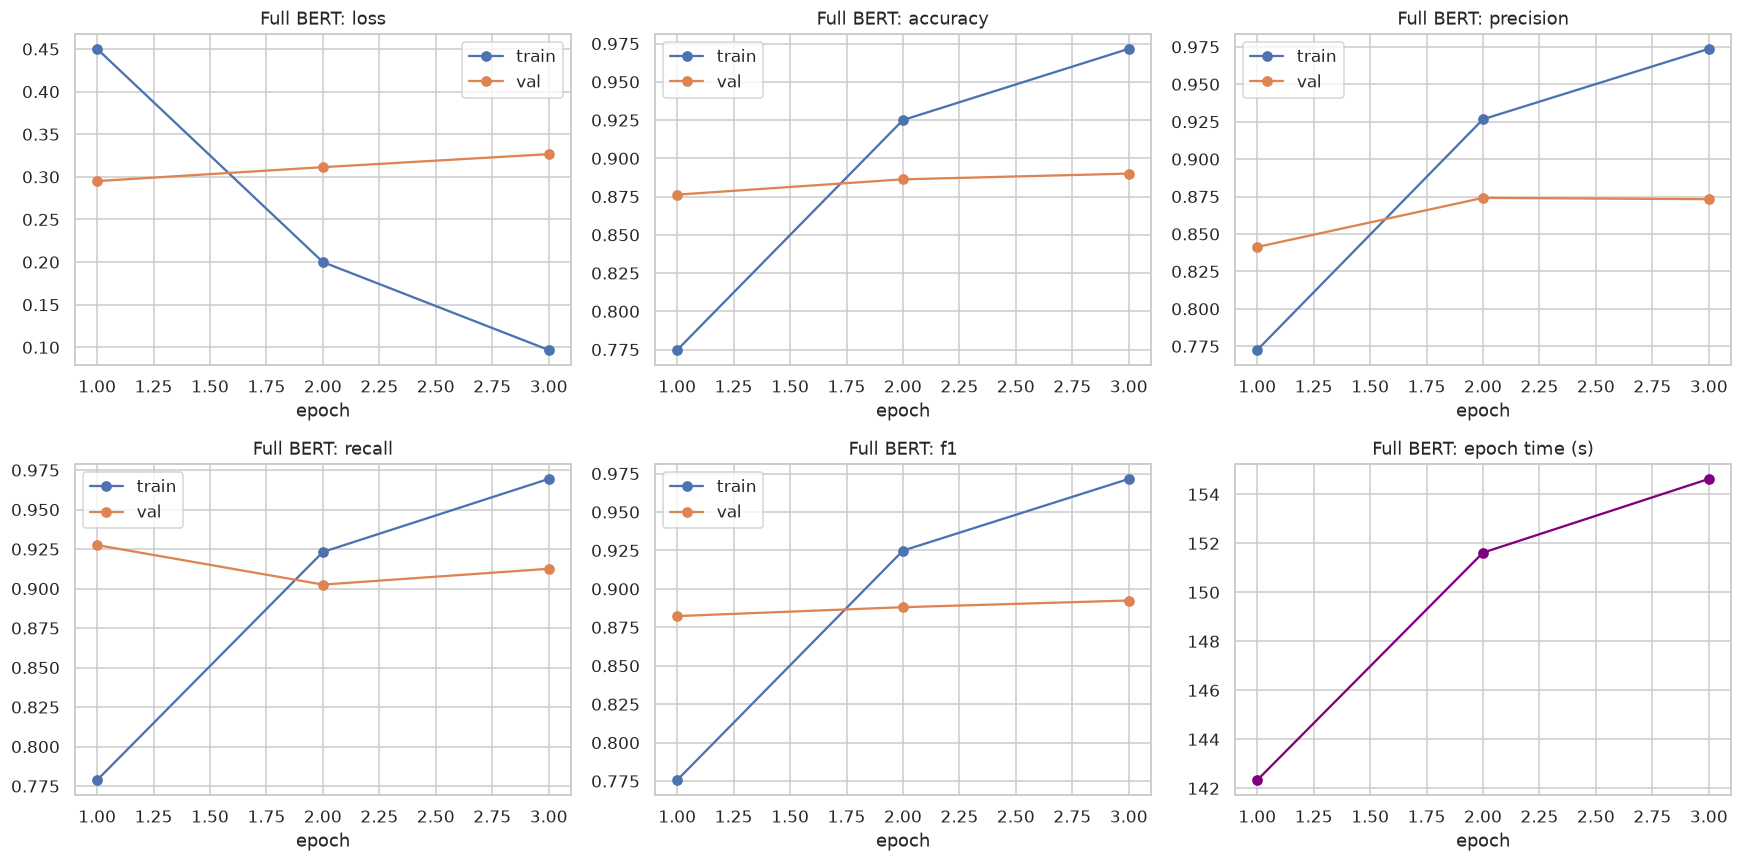

Saved: outputs/plots/full_bert_training_curves.png


In [18]:
def plot_training_curves(run_stats, name, save_path):
    hist = run_stats["history"]
    epochs_range = range(1, len(hist["train"]) + 1)
    metrics_to_plot = ["loss", "accuracy", "precision", "recall", "f1"]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    for i, m in enumerate(metrics_to_plot):
        axes[i].plot(epochs_range, [h[m] for h in hist["train"]], marker="o", label="train")
        axes[i].plot(epochs_range, [h[m] for h in hist["val"]], marker="o", label="val")
        axes[i].set_title(f"{name}: {m}")
        axes[i].set_xlabel("epoch")
        axes[i].legend()

    axes[5].plot(epochs_range, run_stats["epoch_times_sec"], marker="o", color="purple")
    axes[5].set_title(f"{name}: epoch time (s)")
    axes[5].set_xlabel("epoch")

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print("Saved:", save_path)

plot_training_curves(full_run_stats, "Full BERT", f"{OUT}/plots/full_bert_training_curves.png")

## 18. Full BERT — Final Test Evaluation

The best-validation-F1 checkpoint (already reloaded into `full_model` by
`train_model()`) is evaluated **once** on the untouched test set. This is the only time
the test set is used for Full BERT, satisfying Rule 12.

In [19]:
full_test_metrics = evaluate_model(full_model, test_loader)

print("=" * 60)
print("FULL BERT -- FINAL TEST RESULTS")
print("=" * 60)
for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "specificity", "fpr", "fnr"]:
    print(f"{k:12s}: {full_test_metrics[k]:.4f}")

FULL BERT -- FINAL TEST RESULTS
accuracy    : 0.9150
precision   : 0.9014
recall      : 0.9320
f1          : 0.9164
roc_auc     : 0.9705
pr_auc      : 0.9694
specificity : 0.8980
fpr         : 0.1020
fnr         : 0.0680


## Full BERT — Confusion Matrix, ROC, and Precision-Recall Curves

We recompute predictions once more on the test set (for plotting purposes) and generate
the confusion matrix, ROC curve, and PR curve, saved under `outputs/plots/`.

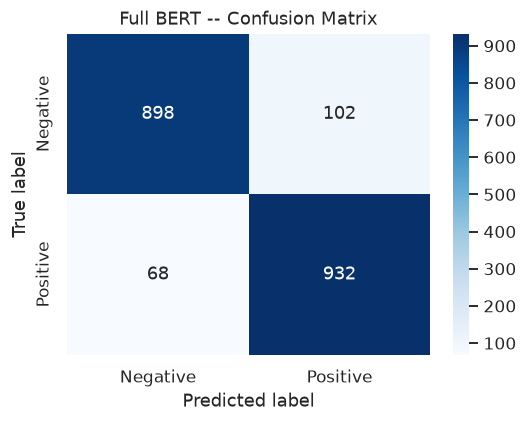

Saved: outputs/plots/full_bert_confusion_matrix.png


In [20]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_labels, all_probs = [], []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
        all_labels.extend(batch["labels"].cpu().numpy().tolist())
        all_probs.extend(probs.tolist())
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)
    return all_labels, all_preds, all_probs

full_test_labels, full_test_preds, full_test_probs = get_predictions(full_model, test_loader)

def plot_confusion(labels, preds, name, save_path):
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.title(f"{name} -- Confusion Matrix")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print("Saved:", save_path)

plot_confusion(full_test_labels, full_test_preds, "Full BERT", f"{OUT}/plots/full_bert_confusion_matrix.png")

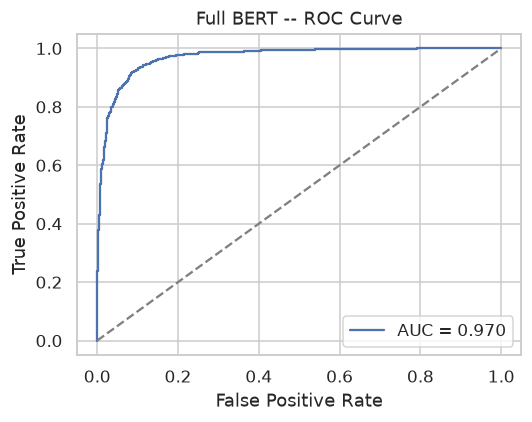

Saved: outputs/plots/full_bert_roc.png


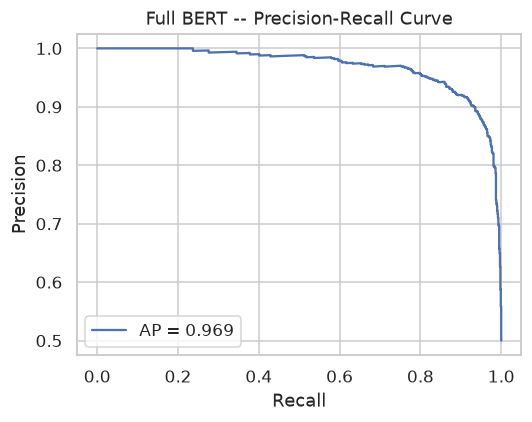

Saved: outputs/plots/full_bert_pr.png


In [21]:
def plot_roc_pr(labels, probs, name, roc_path, pr_path):
    fpr_, tpr_, _ = roc_curve(labels, probs)
    roc_auc_val = roc_auc_score(labels, probs)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr_, tpr_, label=f"AUC = {roc_auc_val:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} -- ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(roc_path)
    plt.show()
    print("Saved:", roc_path)

    prec_, rec_, _ = precision_recall_curve(labels, probs)
    pr_auc_val = average_precision_score(labels, probs)
    plt.figure(figsize=(5, 4))
    plt.plot(rec_, prec_, label=f"AP = {pr_auc_val:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} -- Precision-Recall Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(pr_path)
    plt.show()
    print("Saved:", pr_path)

plot_roc_pr(full_test_labels, full_test_probs, "Full BERT",
            f"{OUT}/plots/full_bert_roc.png", f"{OUT}/plots/full_bert_pr.png")

## 19. Experiment B — LoRA Fine-Tuning

We load a **completely fresh** `bert-base-uncased` checkpoint (not the already-trained
Full BERT model from Experiment A), so both experiments start from the identical
pretrained initialization. We then wrap it with a `LoraConfig` from PEFT:

```
LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none", task_type="SEQ_CLS",
)
```

`target_modules=["query", "value"]` injects low-rank adapters into the query and value
projection matrices of every self-attention layer — the configuration from the original
LoRA paper, and a standard, well-tested choice for BERT-style encoders.

In [22]:
set_seed(CONFIG["seed"])

lora_base_model = BertForSequenceClassification.from_pretrained(
    CONFIG["model_name"], num_labels=CONFIG["num_labels"]
)

lora_config = LoraConfig(
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=CONFIG["lora_target_modules"],
    bias="none",
    task_type=TaskType.SEQ_CLS,
)

lora_model = get_peft_model(lora_base_model, lora_config).to(device)

print("LoRA target modules:", CONFIG["lora_target_modules"])
print()
lora_model.print_trainable_parameters()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LoRA target modules: ['query', 'value']

trainable params: 296,450 || all params: 109,780,228 || trainable%: 0.2700


## 20. LoRA Parameter Analysis

We break down total / trainable / frozen parameters explicitly, separate LoRA-adapter
parameters from classifier-head parameters, and compute the **trainable-parameter
reduction** relative to Full BERT:

```
Reduction = 1 - (LoRA_trainable / Full_trainable)
```

This is one of the primary quantitative outcomes of the experiment (H2).

In [23]:
lora_total_p = sum(p.numel() for p in lora_model.parameters())
lora_trainable_p = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
lora_frozen_p = lora_total_p - lora_trainable_p

lora_adapter_p = sum(
    p.numel() for n, p in lora_model.named_parameters()
    if p.requires_grad and "lora_" in n
)
lora_classifier_p = sum(
    p.numel() for n, p in lora_model.named_parameters()
    if p.requires_grad and "lora_" not in n
)

print("=" * 60)
print("LoRA PARAMETER ANALYSIS")
print("=" * 60)
print(f"Total parameters:      {lora_total_p:,}")
print(f"Trainable parameters:  {lora_trainable_p:,}")
print(f"Frozen parameters:     {lora_frozen_p:,}")
print(f"Trainable percentage:  {100 * lora_trainable_p / lora_total_p:.4f}%")
print()
print(f"LoRA adapter parameters:   {lora_adapter_p:,}")
print(f"Classifier parameters:     {lora_classifier_p:,}")
print("=" * 60)

reduction = 1 - (lora_trainable_p / full_bert_trainable_params)
print()
print(f"Full BERT trainable parameters: {full_bert_trainable_params:,}")
print(f"LoRA trainable parameters:      {lora_trainable_p:,}")
print(f"Trainable parameter reduction:  {100 * reduction:.2f}%")

LoRA PARAMETER ANALYSIS
Total parameters:      109,780,228
Trainable parameters:  296,450
Frozen parameters:     109,483,778
Trainable percentage:  0.2700%

LoRA adapter parameters:   294,912
Classifier parameters:     1,538

Full BERT trainable parameters: 109,483,778
LoRA trainable parameters:      296,450
Trainable parameter reduction:  99.73%


## 21. LoRA Architecture

```
Original BERT
   |
Frozen Transformer weights
   |
LoRA adapters (query, value projections)
   |
Classification head (trainable)
```

For a frozen weight matrix `W` in an attention projection, LoRA does **not** modify `W`
directly. Instead it learns a low-rank update:

```
W' = W + delta_W,     delta_W = B @ A
```

where `A` in R^(r x d), `B` in R^(d x r), and `r << d` (here `r=8` vs. `d=768`).
Only `A` and `B` are trained; `W` stays frozen. Since `r << d`, the number of new
trainable parameters per adapted matrix is `2 * r * d`, which is tiny relative to the
`d * d` parameters of the original matrix — this is the mechanical reason LoRA achieves
the large trainable-parameter reduction reported above.

In [24]:
print("LoRA-modified module structure (attention block, layer 0):")
print(lora_model.base_model.model.bert.encoder.layer[0].attention.self)

LoRA-modified module structure (attention block, layer 0):
BertSdpaSelfAttention(
  (query): lora.Linear(
    (base_layer): Linear(in_features=768, out_features=768, bias=True)
    (lora_dropout): ModuleDict(
      (default): Dropout(p=0.1, inplace=False)
    )
    (lora_A): ModuleDict(
      (default): Linear(in_features=768, out_features=8, bias=False)
    )
    (lora_B): ModuleDict(
      (default): Linear(in_features=8, out_features=768, bias=False)
    )
    (lora_embedding_A): ParameterDict()
    (lora_embedding_B): ParameterDict()
    (lora_magnitude_vector): ModuleDict()
  )
  (key): Linear(in_features=768, out_features=768, bias=True)
  (value): lora.Linear(
    (base_layer): Linear(in_features=768, out_features=768, bias=True)
    (lora_dropout): ModuleDict(
      (default): Dropout(p=0.1, inplace=False)
    )
    (lora_A): ModuleDict(
      (default): Linear(in_features=768, out_features=8, bias=False)
    )
    (lora_B): ModuleDict(
      (default): Linear(in_features=8, ou

## 22. LoRA Memory Baseline (Before Training)

Same protocol as the Full BERT memory baseline (Section 16), so the two are directly
comparable under identical measurement conditions.

In [25]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    alloc = torch.cuda.memory_allocated() / (1024**2)
    reserved = torch.cuda.memory_reserved() / (1024**2)
else:
    alloc = reserved = 0.0

print("=" * 60)
print("LoRA MEMORY -- BEFORE TRAINING")
print("=" * 60)
print(f"Allocated: {alloc:.1f} MB")
print(f"Reserved:  {reserved:.1f} MB")

LoRA MEMORY -- BEFORE TRAINING
Allocated: 877.6 MB
Reserved:  932.0 MB


## 23. LoRA Training

Uses the **same** `train_model()` function, the **same** `train_loader` /
`val_loader`, and the **same** `CONFIG` hyperparameters as Full BERT — the only
difference is that most of `lora_model`'s parameters have `requires_grad=False`.

In [26]:
lora_model, lora_run_stats = train_model(
    lora_model, "LoRA BERT", train_loader, val_loader, CONFIG
)

[LoRA BERT] Epoch 1/3
  Train  - loss: 0.6915 acc: 0.5272 prec: 0.5234 rec: 0.6088 f1: 0.5628
  Val    - loss: 0.6811 acc: 0.5988 prec: 0.6005 rec: 0.5900 f1: 0.5952 roc_auc: 0.6395 pr_auc: 0.6251
  Learning rate: 1.48e-05 | Epoch time: 116.9s

[LoRA BERT] Epoch 2/3
  Train  - loss: 0.6739 acc: 0.5944 prec: 0.5858 rec: 0.6444 f1: 0.6137
  Val    - loss: 0.6617 acc: 0.6700 prec: 0.6692 rec: 0.6725 f1: 0.6708 roc_auc: 0.7168 pr_auc: 0.7028
  Learning rate: 7.41e-06 | Epoch time: 117.2s

[LoRA BERT] Epoch 3/3
  Train  - loss: 0.6608 acc: 0.6347 prec: 0.6363 rec: 0.6288 f1: 0.6325
  Val    - loss: 0.6509 acc: 0.6575 prec: 0.6250 rec: 0.7875 f1: 0.6969 roc_auc: 0.7370 pr_auc: 0.7254
  Learning rate: 0.00e+00 | Epoch time: 117.3s

Total elapsed time for LoRA BERT: 351.5s (best val F1: 0.6969)


## 24. LoRA Training Curves

Same plotting function as Full BERT, saved to `outputs/plots/lora_training_curves.png`.

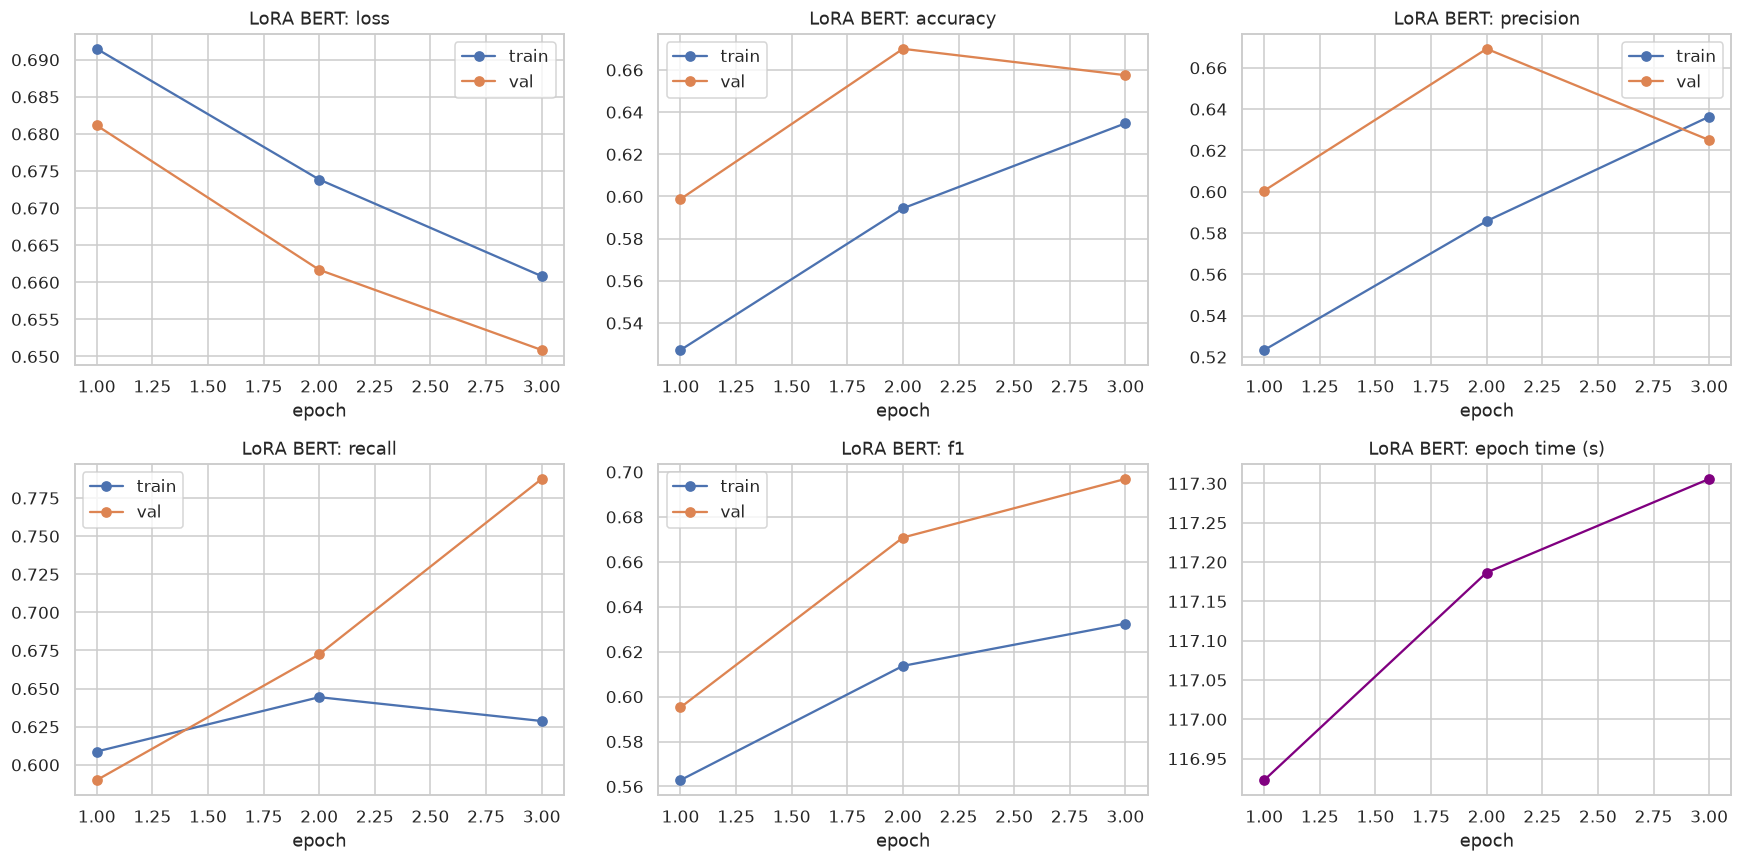

Saved: outputs/plots/lora_training_curves.png


In [27]:
plot_training_curves(lora_run_stats, "LoRA BERT", f"{OUT}/plots/lora_training_curves.png")

## 25. LoRA — Final Test Evaluation

Evaluated once on the **same** untouched test set used for Full BERT.

In [28]:
lora_test_metrics = evaluate_model(lora_model, test_loader)

print("=" * 60)
print("LoRA -- FINAL TEST RESULTS")
print("=" * 60)
for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "specificity", "fpr", "fnr"]:
    print(f"{k:12s}: {lora_test_metrics[k]:.4f}")

LoRA -- FINAL TEST RESULTS
accuracy    : 0.6745
precision   : 0.6386
recall      : 0.8040
f1          : 0.7118
roc_auc     : 0.7539
pr_auc      : 0.7422
specificity : 0.5450
fpr         : 0.4550
fnr         : 0.1960


## LoRA — Confusion Matrix, ROC, and Precision-Recall Curves

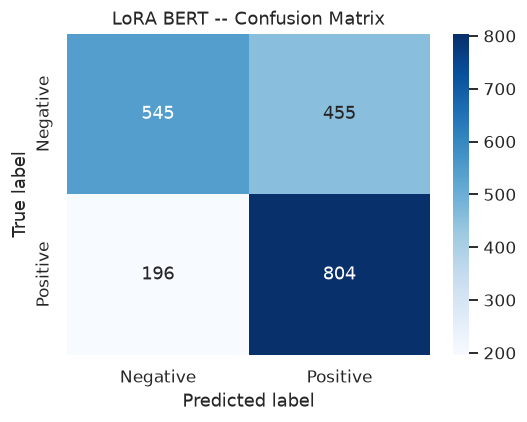

Saved: outputs/plots/lora_confusion_matrix.png


In [29]:
lora_test_labels, lora_test_preds, lora_test_probs = get_predictions(lora_model, test_loader)

plot_confusion(lora_test_labels, lora_test_preds, "LoRA BERT", f"{OUT}/plots/lora_confusion_matrix.png")

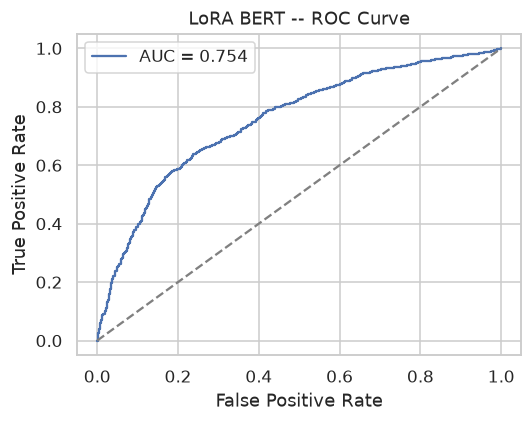

Saved: outputs/plots/lora_roc.png


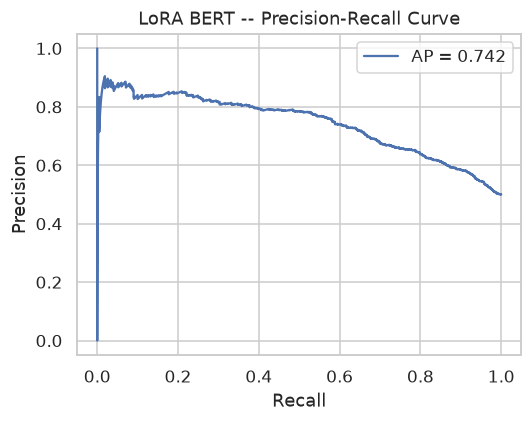

Saved: outputs/plots/lora_pr.png


In [30]:
plot_roc_pr(lora_test_labels, lora_test_probs, "LoRA BERT",
            f"{OUT}/plots/lora_roc.png", f"{OUT}/plots/lora_pr.png")

## 28. GPU Memory Comparison

Compares **peak** allocated / reserved GPU memory recorded during each experiment's
training loop (captured inside `train_model()` via `torch.cuda.max_memory_allocated /
reserved`, reset immediately before each run).

**Caveat (explicitly, per experimental rules):** actual GPU memory savings from LoRA
depend on batch size, optimizer state (Adam keeps two moments per trainable parameter —
far fewer for LoRA), gradient buffers, activation memory (identical for both, since the
frozen backbone still does a full forward pass), numerical precision, and framework
implementation details. **LoRA's memory reduction is not expected to match its
trainable-parameter reduction percentage** — activations and the frozen base model's
forward-pass memory dominate for a model this size, and those costs are shared by both
experiments.

In [31]:
full_peak_alloc = full_run_stats["peak_allocated_mb"]
full_peak_reserved = full_run_stats["peak_reserved_mb"]
lora_peak_alloc = lora_run_stats["peak_allocated_mb"]
lora_peak_reserved = lora_run_stats["peak_reserved_mb"]

mem_reduction_mb = full_peak_alloc - lora_peak_alloc
mem_reduction_pct = (mem_reduction_mb / full_peak_alloc * 100) if full_peak_alloc > 0 else float("nan")

print("=" * 60)
print("GPU MEMORY COMPARISON")
print("=" * 60)
print(f"{'Metric':<22}{'Full BERT':>15}{'LoRA':>15}")
print("-" * 52)
print(f"{'Peak allocated (MB)':<22}{full_peak_alloc:>15.1f}{lora_peak_alloc:>15.1f}")
print(f"{'Peak reserved (MB)':<22}{full_peak_reserved:>15.1f}{lora_peak_reserved:>15.1f}")
print("-" * 52)
print(f"Memory reduction:      {mem_reduction_mb:.1f} MB")
print(f"Memory reduction %:    {mem_reduction_pct:.2f}%")
print()
print("NOTE: this reduction reflects optimizer-state and gradient-buffer savings from "
      "having far fewer trainable parameters. It does NOT eliminate the memory cost "
      "of the frozen base model or activations, both of which are present in both runs.")

GPU MEMORY COMPARISON
Metric                      Full BERT           LoRA
----------------------------------------------------
Peak allocated (MB)            4242.5         3307.0
Peak reserved (MB)             4368.0         3494.0
----------------------------------------------------
Memory reduction:      935.5 MB
Memory reduction %:    22.05%

NOTE: this reduction reflects optimizer-state and gradient-buffer savings from having far fewer trainable parameters. It does NOT eliminate the memory cost of the frozen base model or activations, both of which are present in both runs.


## 29. Training Time Comparison

Compares total training time, average epoch time, and average step time between the two
experiments, using `torch.cuda.synchronize()`-bounded timers inside `train_model()` so
that GPU kernel execution is fully accounted for (not just CPU-side dispatch time).

In [32]:
time_diff = full_run_stats["total_time_sec"] - lora_run_stats["total_time_sec"]
time_diff_pct = (time_diff / full_run_stats["total_time_sec"] * 100) if full_run_stats["total_time_sec"] > 0 else float("nan")

print("=" * 60)
print("TRAINING TIME COMPARISON")
print("=" * 60)
print(f"{'Metric':<22}{'Full BERT':>15}{'LoRA':>15}")
print("-" * 52)
print(f"{'Total time (s)':<22}{full_run_stats['total_time_sec']:>15.1f}{lora_run_stats['total_time_sec']:>15.1f}")
print(f"{'Avg epoch time (s)':<22}{full_run_stats['avg_epoch_time_sec']:>15.1f}{lora_run_stats['avg_epoch_time_sec']:>15.1f}")
print(f"{'Avg step time (s)':<22}{full_run_stats['avg_step_time_sec']:>15.3f}{lora_run_stats['avg_step_time_sec']:>15.3f}")
print("-" * 52)
print(f"Time difference (Full - LoRA):    {time_diff:.1f} s")
print(f"Percentage difference:            {time_diff_pct:.2f}%")

TRAINING TIME COMPARISON
Metric                      Full BERT           LoRA
----------------------------------------------------
Total time (s)                  448.6          351.5
Avg epoch time (s)              149.5          117.1
Avg step time (s)               0.748          0.586
----------------------------------------------------
Time difference (Full - LoRA):    97.1 s
Percentage difference:            21.65%


## 30. Inference Time Comparison

Measures inference latency/throughput for both models on the **same** test subset, same
batch size, same device, and same precision (fp32, no autocast), using
`torch.cuda.synchronize()` around the timed region.

In [33]:
@torch.no_grad()
def measure_inference_time(model, loader):
    model.eval()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    n_samples = 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        _ = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        n_samples += batch["labels"].size(0)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    total_time = time.time() - t0
    return total_time, total_time / n_samples, n_samples / total_time

full_total_inf, full_per_sample, full_throughput = measure_inference_time(full_model, test_loader)
lora_total_inf, lora_per_sample, lora_throughput = measure_inference_time(lora_model, test_loader)

print("=" * 60)
print("INFERENCE PERFORMANCE")
print("=" * 60)
print("Full BERT:")
print(f"  Total:       {full_total_inf:.2f} s")
print(f"  Per sample:  {full_per_sample*1000:.2f} ms")
print(f"  Samples/sec: {full_throughput:.1f}")
print()
print("LoRA:")
print(f"  Total:       {lora_total_inf:.2f} s")
print(f"  Per sample:  {lora_per_sample*1000:.2f} ms")
print(f"  Samples/sec: {lora_throughput:.1f}")
print()
print("NOTE: LoRA adapters add a small amount of extra compute (low-rank matmuls) "
      "relative to the frozen base model's forward pass, so inference time is "
      "expected to be roughly comparable to -- not necessarily faster than -- Full BERT.")

INFERENCE PERFORMANCE
Full BERT:
  Total:       29.71 s
  Per sample:  14.86 ms
  Samples/sec: 67.3

LoRA:
  Total:       30.40 s
  Per sample:  15.20 ms
  Samples/sec: 65.8

NOTE: LoRA adapters add a small amount of extra compute (low-rank matmuls) relative to the frozen base model's forward pass, so inference time is expected to be roughly comparable to -- not necessarily faster than -- Full BERT.


## 31. Model Storage Size

Saves the **full** Full-BERT checkpoint and the **LoRA adapter only** (via PEFT's
`save_pretrained`, which by design stores just the adapter weights, not the frozen base
model) and measures on-disk size in MB.

In [34]:
full_model_path = f"{OUT}/models/full_bert/pytorch_model.bin"
torch.save(full_model.state_dict(), full_model_path)
full_model_size_mb = os.path.getsize(full_model_path) / (1024**2)

lora_adapter_dir = f"{OUT}/models/lora/adapter"
lora_model.save_pretrained(lora_adapter_dir)

def dir_size_mb(path):
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return total / (1024**2)

lora_adapter_size_mb = dir_size_mb(lora_adapter_dir)
storage_reduction_pct = (1 - lora_adapter_size_mb / full_model_size_mb) * 100

print("=" * 60)
print("MODEL STORAGE COMPARISON")
print("=" * 60)
print(f"Full BERT checkpoint: {full_model_size_mb:.1f} MB")
print(f"LoRA adapter:         {lora_adapter_size_mb:.1f} MB")
print(f"Storage reduction:    {storage_reduction_pct:.2f}%")
print()
print("NOTE: the LoRA adapter directory stores ONLY the trainable low-rank matrices "
      "(and classifier head) -- reloading it for inference still requires the frozen "
      "bert-base-uncased base checkpoint to be loaded alongside it.")

MODEL STORAGE COMPARISON
Full BERT checkpoint: 417.7 MB
LoRA adapter:         1.1 MB
Storage reduction:    99.73%

NOTE: the LoRA adapter directory stores ONLY the trainable low-rank matrices (and classifier head) -- reloading it for inference still requires the frozen bert-base-uncased base checkpoint to be loaded alongside it.


## 32. Parameter Comparison Graph

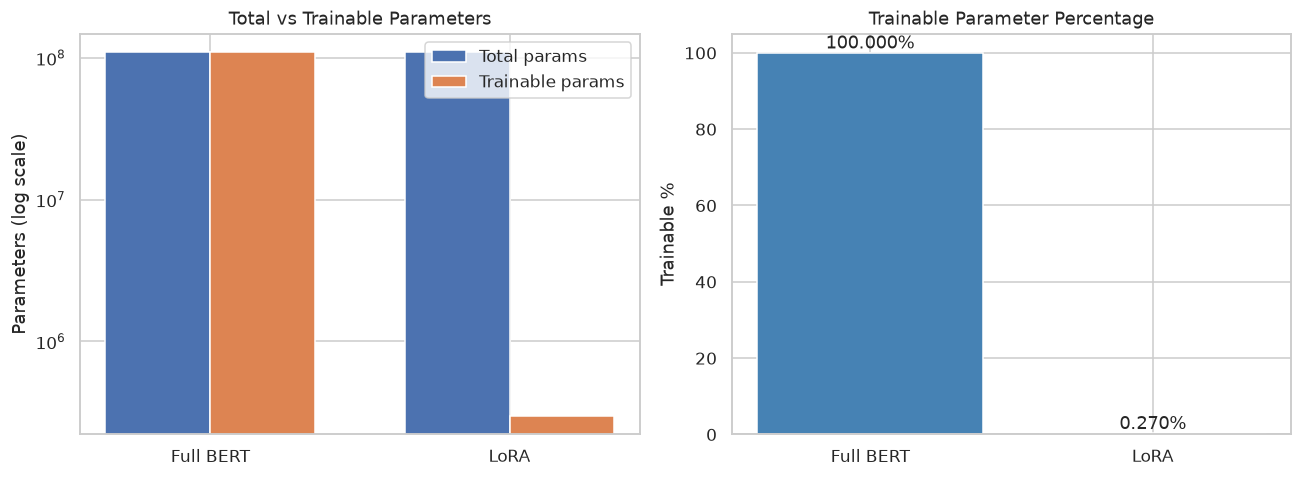

Saved: outputs/plots/parameter_comparison.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

labels_bar = ["Full BERT", "LoRA"]
totals = [full_bert_total_params, lora_total_p]
trainables = [full_bert_trainable_params, lora_trainable_p]

x = np.arange(len(labels_bar))
width = 0.35
axes[0].bar(x - width/2, totals, width, label="Total params")
axes[0].bar(x + width/2, trainables, width, label="Trainable params")
axes[0].set_yscale("log")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_bar)
axes[0].set_ylabel("Parameters (log scale)")
axes[0].set_title("Total vs Trainable Parameters")
axes[0].legend()

pct = [100 * full_bert_trainable_params / full_bert_total_params, 100 * lora_trainable_p / lora_total_p]
axes[1].bar(labels_bar, pct, color=["steelblue", "darkorange"])
axes[1].set_ylabel("Trainable %")
axes[1].set_title("Trainable Parameter Percentage")
for i, v in enumerate(pct):
    axes[1].text(i, v, f"{v:.3f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(f"{OUT}/plots/parameter_comparison.png")
plt.show()
print("Saved:", f"{OUT}/plots/parameter_comparison.png")

## 33. Memory Comparison Graph

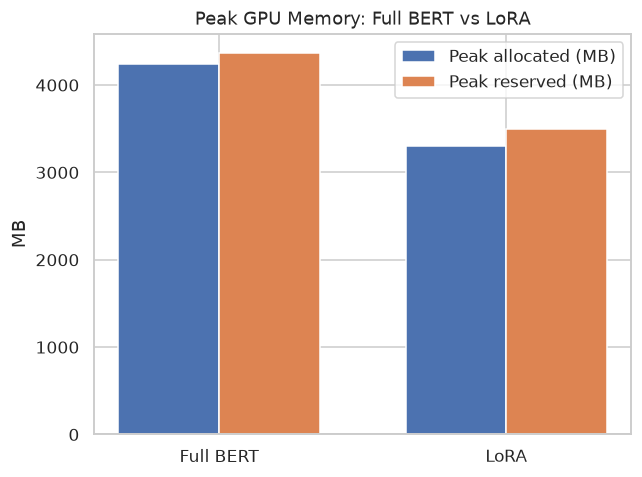

Saved: outputs/plots/memory_comparison.png


In [36]:
plt.figure(figsize=(6, 4.5))
x = np.arange(2)
width = 0.35
plt.bar(x - width/2, [full_peak_alloc, lora_peak_alloc], width, label="Peak allocated (MB)")
plt.bar(x + width/2, [full_peak_reserved, lora_peak_reserved], width, label="Peak reserved (MB)")
plt.xticks(x, ["Full BERT", "LoRA"])
plt.ylabel("MB")
plt.title("Peak GPU Memory: Full BERT vs LoRA")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/plots/memory_comparison.png")
plt.show()
print("Saved:", f"{OUT}/plots/memory_comparison.png")

## 34. Training Time Graph

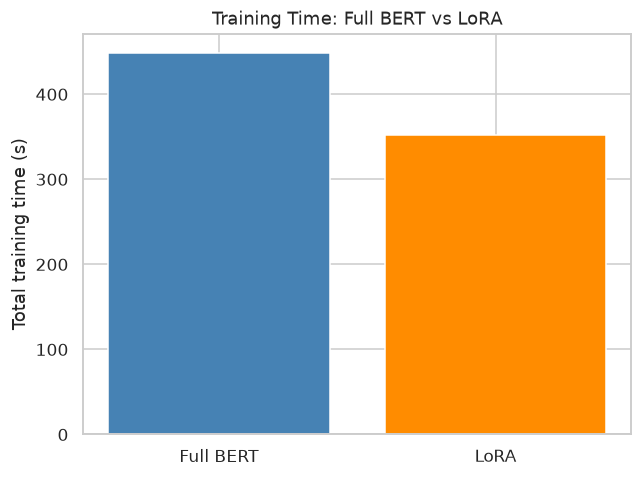

Saved: outputs/plots/training_time_comparison.png


In [37]:
plt.figure(figsize=(6, 4.5))
plt.bar(["Full BERT", "LoRA"],
        [full_run_stats["total_time_sec"], lora_run_stats["total_time_sec"]],
        color=["steelblue", "darkorange"])
plt.ylabel("Total training time (s)")
plt.title("Training Time: Full BERT vs LoRA")
plt.tight_layout()
plt.savefig(f"{OUT}/plots/training_time_comparison.png")
plt.show()
print("Saved:", f"{OUT}/plots/training_time_comparison.png")

## 35. Final Performance Comparison Table

Consolidates every measured metric for both experiments into a single DataFrame, saved
to `outputs/tables/final_comparison.csv`.

In [38]:
comparison_rows = []
for name, test_metrics, run_stats, total_p_, trainable_p_, size_mb, inf_total, inf_per_sample in [
    ("Full BERT", full_test_metrics, full_run_stats, full_bert_total_params, full_bert_trainable_params, full_model_size_mb, full_total_inf, full_per_sample),
    ("LoRA BERT", lora_test_metrics, lora_run_stats, lora_total_p, lora_trainable_p, lora_adapter_size_mb, lora_total_inf, lora_per_sample),
]:
    comparison_rows.append({
        "Model": name,
        "Accuracy": test_metrics["accuracy"],
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1": test_metrics["f1"],
        "ROC-AUC": test_metrics["roc_auc"],
        "PR-AUC": test_metrics["pr_auc"],
        "Specificity": test_metrics["specificity"],
        "FPR": test_metrics["fpr"],
        "FNR": test_metrics["fnr"],
        "Trainable Parameters": trainable_p_,
        "Trainable %": 100 * trainable_p_ / total_p_,
        "Peak GPU Memory (MB)": run_stats["peak_allocated_mb"],
        "Training Time (s)": run_stats["total_time_sec"],
        "Inference Time (s)": inf_total,
        "Checkpoint Size (MB)": size_mb,
    })

final_comparison_df = pd.DataFrame(comparison_rows)
final_comparison_df.to_csv(f"{OUT}/tables/final_comparison.csv", index=False)
final_comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Specificity,FPR,FNR,Trainable Parameters,Trainable %,Peak GPU Memory (MB),Training Time (s),Inference Time (s),Checkpoint Size (MB)
0,Full BERT,0.9150,0.901354,0.932,0.916421,0.970465,0.969364,0.898,0.102,0.068,109483778,100.00000,4242.534668,448.618532,29.713022,417.726874
1,LoRA BERT,0.6745,0.638602,0.804,0.711819,0.753883,0.742181,0.545,0.455,0.196,296450,0.27004,3306.990723,351.472274,30.397329,1.142913


## 36. Performance Visualization

Grouped bar chart of Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC for both
models.

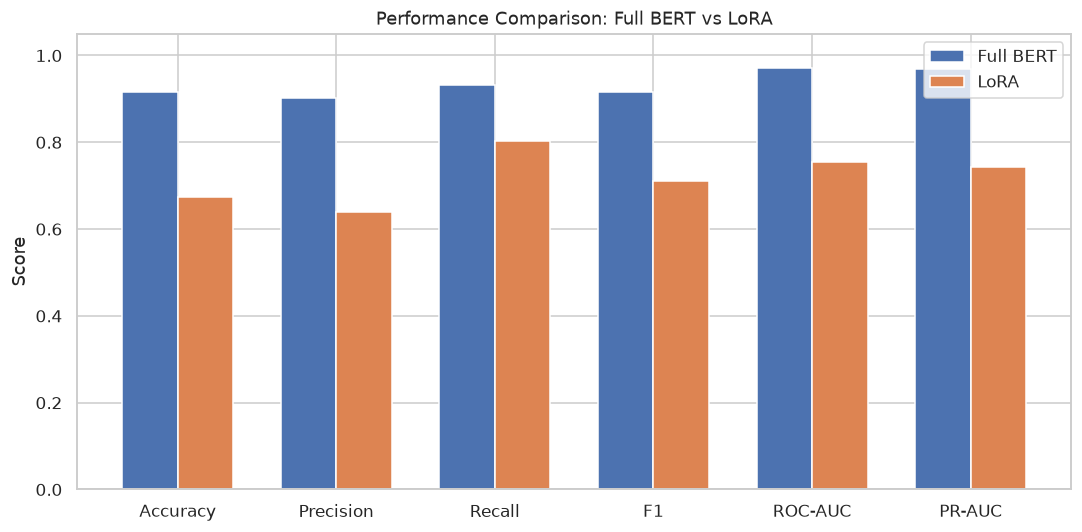

Saved: outputs/plots/performance_comparison.png


In [39]:
metrics_for_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
x = np.arange(len(metrics_for_plot))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, final_comparison_df.iloc[0][metrics_for_plot], width, label="Full BERT")
plt.bar(x + width/2, final_comparison_df.iloc[1][metrics_for_plot], width, label="LoRA")
plt.xticks(x, metrics_for_plot)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Performance Comparison: Full BERT vs LoRA")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/plots/performance_comparison.png")
plt.show()
print("Saved:", f"{OUT}/plots/performance_comparison.png")

## 37. Error Analysis

Builds a per-example DataFrame with both models' predictions/probabilities on the test
set and categorizes examples into: both correct, both wrong, Full-only-correct, and
LoRA-only-correct, then displays representative examples of each.

In [40]:
assert np.array_equal(full_test_labels, lora_test_labels), "Test label order mismatch!"

error_df = pd.DataFrame({
    "text": test_split_df["text"].values,
    "true_label": full_test_labels,
    "full_bert_prediction": full_test_preds,
    "full_bert_probability": full_test_probs,
    "lora_prediction": lora_test_preds,
    "lora_probability": lora_test_probs,
})
error_df["full_correct"] = error_df["full_bert_prediction"] == error_df["true_label"]
error_df["lora_correct"] = error_df["lora_prediction"] == error_df["true_label"]

both_correct = error_df[error_df["full_correct"] & error_df["lora_correct"]]
both_wrong = error_df[~error_df["full_correct"] & ~error_df["lora_correct"]]
full_only = error_df[error_df["full_correct"] & ~error_df["lora_correct"]]
lora_only = error_df[~error_df["full_correct"] & error_df["lora_correct"]]

print(f"Both models correct:            {len(both_correct)} ({100*len(both_correct)/len(error_df):.1f}%)")
print(f"Both models wrong:              {len(both_wrong)} ({100*len(both_wrong)/len(error_df):.1f}%)")
print(f"Full BERT correct, LoRA wrong:  {len(full_only)} ({100*len(full_only)/len(error_df):.1f}%)")
print(f"LoRA correct, Full BERT wrong:  {len(lora_only)} ({100*len(lora_only)/len(error_df):.1f}%)")

error_df.to_csv(f"{OUT}/errors/error_analysis_full.csv", index=False)

print()
print("--- Example: both models wrong ---")
if len(both_wrong) > 0:
    print(both_wrong.iloc[0]["text"][:300], "...")

print()
print("--- Example: Full correct, LoRA wrong ---")
if len(full_only) > 0:
    print(full_only.iloc[0]["text"][:300], "...")

print()
print("--- Example: LoRA correct, Full wrong ---")
if len(lora_only) > 0:
    print(lora_only.iloc[0]["text"][:300], "...")

Both models correct:            1298 (64.9%)
Both models wrong:              119 (6.0%)
Full BERT correct, LoRA wrong:  532 (26.6%)
LoRA correct, Full BERT wrong:  51 (2.5%)

--- Example: both models wrong ---
We don't know if Darlene loves all three gentleman, certainly they are wary of one another, yet they live together. Viewers might surmise that the feelings of rivalry between the gentleman and the feelings of all of them toward Darlene might make for an unbearable home life.<br /><br />In the eerily ...

--- Example: Full correct, LoRA wrong ---
Of all the adaptations of books by Alistair MacLean, I feel that this qualifies as the worst, but don´t blame MacLean!. It would appear that all that this film shares with the novel is the same title. We have no suspense, no sense of foreboding of mystery, no chance to really empathize with the main ...

--- Example: LoRA correct, Full wrong ---
So far I disliked every single Jean Rollin movie I've seen, and that always bothered me becaus

## 38. Prediction Agreement

Measures how often Full BERT and LoRA agree on the predicted class, independent of
whether either is correct.

In [41]:
agreement_mask = error_df["full_bert_prediction"] == error_df["lora_prediction"]
agreement_pct = 100 * agreement_mask.mean()
disagreement_pct = 100 - agreement_pct

print(f"Agreement percentage:    {agreement_pct:.2f}%")
print(f"Disagreement percentage: {disagreement_pct:.2f}%")

agreement_matrix = pd.crosstab(
    error_df["full_bert_prediction"].map({0: "Full: Neg", 1: "Full: Pos"}),
    error_df["lora_prediction"].map({0: "LoRA: Neg", 1: "LoRA: Pos"}),
)
print()
print("Prediction agreement matrix:")
print(agreement_matrix)

disagreements = error_df[~agreement_mask]
print()
print(f"{len(disagreements)} disagreement examples found. Example:")
if len(disagreements) > 0:
    row = disagreements.iloc[0]
    print(f"  True label: {row['true_label']} | Full pred: {row['full_bert_prediction']} "
          f"({row['full_bert_probability']:.3f}) | LoRA pred: {row['lora_prediction']} ({row['lora_probability']:.3f})")
    print("  Text:", row["text"][:300], "...")

Agreement percentage:    70.85%
Disagreement percentage: 29.15%

Prediction agreement matrix:
lora_prediction       LoRA: Neg  LoRA: Pos
full_bert_prediction                      
Full: Neg                   562        404
Full: Pos                   179        855

583 disagreement examples found. Example:
  True label: 0 | Full pred: 1 (0.942) | LoRA pred: 0 (0.481)
  Text: So far I disliked every single Jean Rollin movie I've seen, and that always bothered me because he's an acclaimed Euro-trash monument and extremely popular amongst many regular reviewers on this lovely website; people whose opinions I always value and usually concur with. Apparently everybody always ...


## 39. Explainability — Integrated Gradients

We use **Captum's Integrated Gradients** to compute token-level attributions for four
representative examples (correct positive, correct negative, false positive, false
negative — selected from `error_df`), for **both** models, and compare which tokens each
model relies on most.

**Important distinction:** this is a genuine *attribution*-based explanation (gradients
integrated along a path from a baseline to the actual input embedding), which is
different from raw attention weights (Section 40). Attention weights show where the
model *looks*; they are not a validated causal explanation of *why* it made a
prediction. We do not conflate the two here.

In [42]:
from captum.attr import LayerIntegratedGradients

def get_word_embedding_layer(model):
    # Works for both a plain BertForSequenceClassification and a PEFT-wrapped model.
    try:
        return model.bert.embeddings.word_embeddings
    except AttributeError:
        return model.base_model.model.bert.embeddings.word_embeddings

def predict_forward(model):
    def _forward(input_ids, attention_mask):
        return model(input_ids=input_ids, attention_mask=attention_mask).logits
    return _forward

def explain_example(model, text, true_label, model_name, max_len=64):
    model.eval()
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                     max_length=max_len, padding="max_length").to(device)
    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]

    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id)
    baseline_ids[:, 0] = input_ids[0, 0]  # keep [CLS]

    lig = LayerIntegratedGradients(predict_forward(model), get_word_embedding_layer(model))
    attributions, _ = lig.attribute(
        inputs=input_ids, baselines=baseline_ids,
        additional_forward_args=(attention_mask,),
        target=int(true_label), n_steps=24, return_convergence_delta=True,
    )
    attr_scores = attributions.sum(dim=-1).squeeze(0)
    attr_scores = (attr_scores / attr_scores.norm()).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())

    n_real = int(attention_mask[0].sum().item())
    print(f"[{model_name}] top attributed tokens (true label={true_label}):")
    pairs = sorted(zip(tokens[:n_real], attr_scores[:n_real]), key=lambda x: -abs(x[1]))
    for tok, score in pairs[:10]:
        print(f"  {tok:15s} {score:+.4f}")
    print()
    return tokens[:n_real], attr_scores[:n_real]

# Select representative examples from the error analysis dataframe
correct_pos_row = error_df[(error_df["true_label"] == 1) & error_df["full_correct"] & error_df["lora_correct"]].iloc[0]
correct_neg_row = error_df[(error_df["true_label"] == 0) & error_df["full_correct"] & error_df["lora_correct"]].iloc[0]
fp_candidates = error_df[(error_df["true_label"] == 0) & (error_df["full_bert_prediction"] == 1)]
fn_candidates = error_df[(error_df["true_label"] == 1) & (error_df["full_bert_prediction"] == 0)]

examples = {"correct_positive": correct_pos_row, "correct_negative": correct_neg_row}
if len(fp_candidates) > 0:
    examples["false_positive"] = fp_candidates.iloc[0]
if len(fn_candidates) > 0:
    examples["false_negative"] = fn_candidates.iloc[0]

for case_name, row in examples.items():
    print("=" * 60)
    print(f"CASE: {case_name}")
    print("=" * 60)
    explain_example(full_model, row["text"], row["true_label"], "Full BERT")
    explain_example(lora_model, row["text"], row["true_label"], "LoRA BERT")

CASE: correct_positive
[Full BERT] top attributed tokens (true label=1):
  [SEP]           -0.7008
  love            +0.3668
  together        +0.2735
  first           +0.2533
  well            +0.2151
  they            +0.1892
  think           +0.1459
  work            +0.1283
  fell            +0.1128
  i               +0.1128

[LoRA BERT] top attributed tokens (true label=1):
  [SEP]           -0.5632
  movie           +0.3633
  paula           +0.2715
  saturday        +0.2401
  movie           +0.2149
  .               +0.2062
  .               +0.2034
  1981            +0.1717
  movie           +0.1695
  this            -0.1656

CASE: correct_negative
[Full BERT] top attributed tokens (true label=0):
  [SEP]           +0.9459
  grief           +0.1359
  movie           +0.1192
  good            -0.1139
  bad             +0.1103
  movie           +0.0854
  oh              +0.0686
  .               +0.0680
  tv              +0.0519
  .               +0.0476

[LoRA BERT] top attri

## 40. Attention Comparison

Extracts self-attention weights (`output_attentions=True`) for one representative
example, from both models, for a selected layer/head, and visualizes them side by side.
As noted in Section 39, this shows attention *patterns*, not a causal explanation of the
prediction — we describe only what is observed, without claiming the attention weights
"explain" the decision.

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


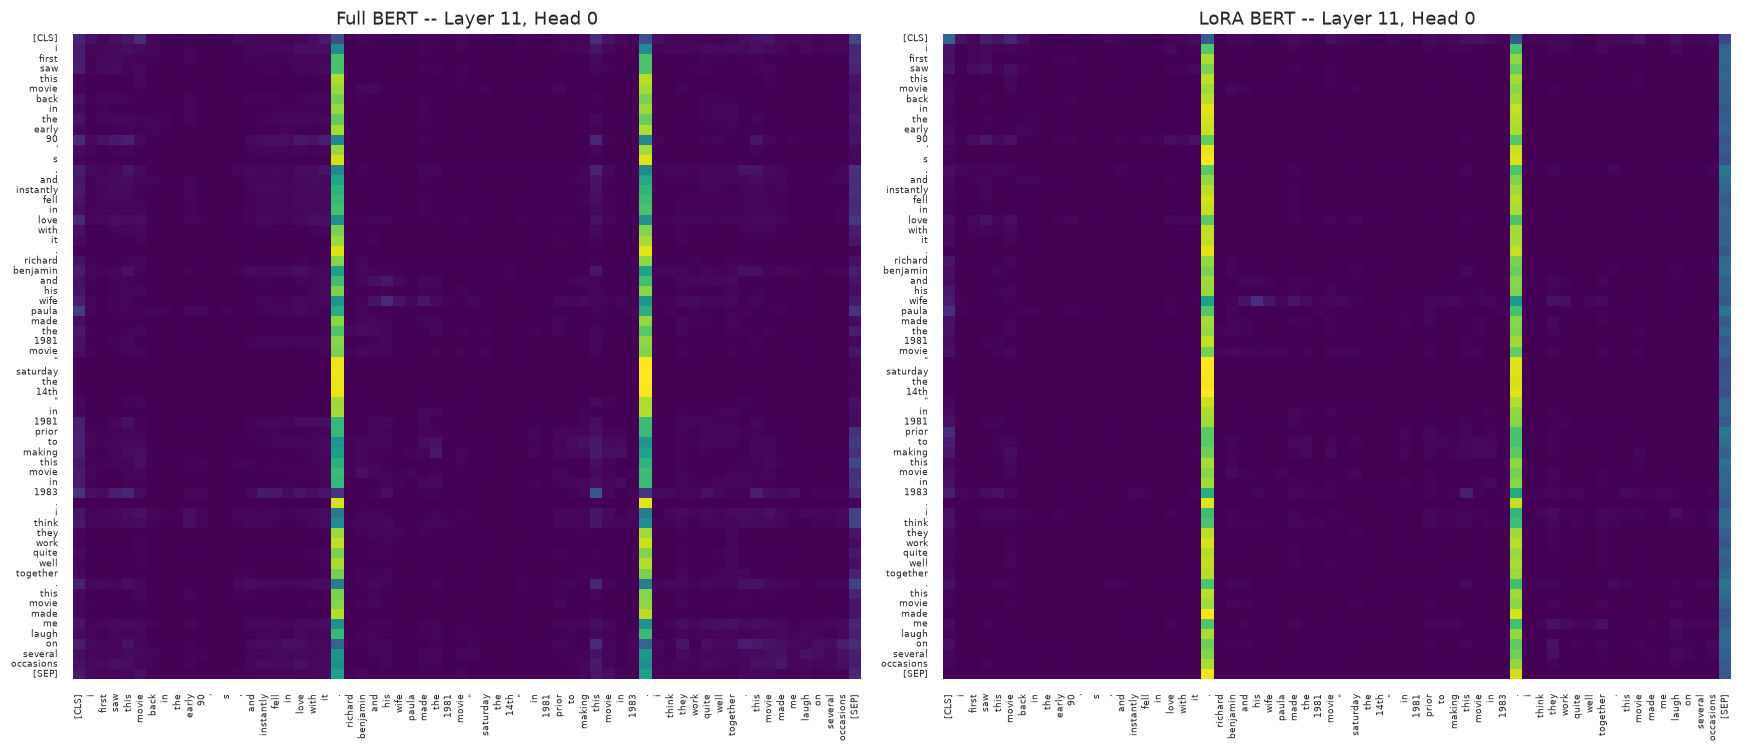

Saved: outputs/plots/attention_comparison.png
Mean absolute attention-weight difference (this layer/head/example): 0.0056
This is a descriptive observation for this single example/layer/head only -- it is not evidence of a general causal difference in model behavior.


In [43]:
@torch.no_grad()
def get_attention(model, text, max_len=64, layer_idx=-1, head_idx=0):
    model.eval()
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                     max_length=max_len, padding="max_length").to(device)
    outputs = model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"],
                     output_attentions=True)
    attn = outputs.attentions[layer_idx][0, head_idx].cpu().numpy()  # [seq, seq]
    n_real = int(enc["attention_mask"][0].sum().item())
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].cpu())[:n_real]
    return attn[:n_real, :n_real], tokens

sample_text = correct_pos_row["text"]
layer_to_show, head_to_show = 11, 0

full_attn, full_tokens = get_attention(full_model, sample_text, layer_idx=layer_to_show, head_idx=head_to_show)
lora_attn, lora_tokens = get_attention(lora_model, sample_text, layer_idx=layer_to_show, head_idx=head_to_show)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(full_attn, xticklabels=full_tokens, yticklabels=full_tokens, ax=axes[0], cmap="viridis", cbar=False)
axes[0].set_title(f"Full BERT -- Layer {layer_to_show}, Head {head_to_show}")
axes[0].tick_params(axis="x", rotation=90, labelsize=6)
axes[0].tick_params(axis="y", labelsize=6)

sns.heatmap(lora_attn, xticklabels=lora_tokens, yticklabels=lora_tokens, ax=axes[1], cmap="viridis", cbar=False)
axes[1].set_title(f"LoRA BERT -- Layer {layer_to_show}, Head {head_to_show}")
axes[1].tick_params(axis="x", rotation=90, labelsize=6)
axes[1].tick_params(axis="y", labelsize=6)

plt.tight_layout()
plt.savefig(f"{OUT}/plots/attention_comparison.png")
plt.show()
print("Saved:", f"{OUT}/plots/attention_comparison.png")

attn_diff = np.abs(full_attn - lora_attn).mean()
print(f"Mean absolute attention-weight difference (this layer/head/example): {attn_diff:.4f}")
print("This is a descriptive observation for this single example/layer/head only -- "
      "it is not evidence of a general causal difference in model behavior.")

## 41. Layer-by-Layer Analysis

For a single representative input, we hook into each encoder layer's output (plus
embeddings, pooler, classifier) and report output shape, mean activation, standard
deviation, and L2 norm — for both models. For LoRA, we additionally list which modules
have LoRA adapters attached and how many LoRA-specific trainable parameters each has.

In [44]:
def layer_activation_report(model, text, model_name, max_len=64):
    model.eval()
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                     max_length=max_len, padding="max_length").to(device)

    activations = {}
    hooks = []

    def make_hook(name):
        def hook(module, inp, out):
            t = out[0] if isinstance(out, tuple) else out
            activations[name] = t.detach()
        return hook

    try:
        bert_module = model.bert
        classifier_module = model.classifier
    except AttributeError:
        bert_module = model.base_model.model.bert
        classifier_module = model.base_model.model.classifier

    hooks.append(bert_module.embeddings.register_forward_hook(make_hook("embeddings")))
    for i, layer in enumerate(bert_module.encoder.layer):
        hooks.append(layer.register_forward_hook(make_hook(f"layer_{i+1}")))
    hooks.append(bert_module.pooler.register_forward_hook(make_hook("pooler")))
    hooks.append(classifier_module.register_forward_hook(make_hook("classifier")))

    with torch.no_grad():
        model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])

    for h in hooks:
        h.remove()

    print(f"--- {model_name}: layer-by-layer activation report ---")
    for name, t in activations.items():
        print(f"{name:12s} shape={tuple(t.shape)!s:20s} mean={t.float().mean().item():+.4f} "
              f"std={t.float().std().item():.4f} L2={t.float().norm().item():.2f}")
    print()
    return activations

_ = layer_activation_report(full_model, sample_text, "Full BERT")
_ = layer_activation_report(lora_model, sample_text, "LoRA BERT")

print("LoRA-enabled modules and their trainable parameter counts:")
for n, p in lora_model.named_parameters():
    if p.requires_grad and "lora_" in n:
        print(f"  {n:70s} {p.numel():>8,}")

--- Full BERT: layer-by-layer activation report ---
embeddings   shape=(1, 64, 768)         mean=+0.0131 std=0.5431 L2=120.45
layer_1      shape=(1, 64, 768)         mean=-0.0205 std=0.6563 L2=145.57
layer_2      shape=(1, 64, 768)         mean=-0.0180 std=0.7239 L2=160.54
layer_3      shape=(1, 64, 768)         mean=-0.0192 std=0.7111 L2=157.70
layer_4      shape=(1, 64, 768)         mean=-0.0265 std=0.7363 L2=163.35
layer_5      shape=(1, 64, 768)         mean=-0.0241 std=0.7625 L2=169.14
layer_6      shape=(1, 64, 768)         mean=-0.0270 std=0.7769 L2=172.34
layer_7      shape=(1, 64, 768)         mean=-0.0279 std=0.7690 L2=170.60
layer_8      shape=(1, 64, 768)         mean=-0.0287 std=0.7355 L2=163.19
layer_9      shape=(1, 64, 768)         mean=-0.0278 std=0.7013 L2=155.60
layer_10     shape=(1, 64, 768)         mean=-0.0282 std=0.7363 L2=163.35
layer_11     shape=(1, 64, 768)         mean=-0.0336 std=0.7563 L2=167.85
layer_12     shape=(1, 64, 768)         mean=-0.0170 std=0.6

## 42. Final Classification Layer

Sentiment prediction pipeline:

```
Input text -> Tokenizer -> Embeddings -> 12 Transformer encoder layers ->
[CLS] representation -> Classification head -> Linear layer -> 2 logits ->
Softmax -> Negative / Positive
```

The prediction is produced entirely by the classification head applied to BERT's
contextual `[CLS]` representation. **LoRA does not replace the BERT model** — it
modifies selected weight *transformations* (query/value projections) with trainable
low-rank adapters; the rest of the forward pass (embeddings, most of attention,
feed-forward blocks, pooling, and the final linear classifier) executes the same
architecture as Full BERT.

In [45]:
@torch.no_grad()
def classification_breakdown(model, text, model_name, max_len=64):
    model.eval()
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                     max_length=max_len, padding="max_length").to(device)
    outputs = model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"],
                     output_hidden_states=True)
    cls_hidden = outputs.hidden_states[-1][:, 0, :]
    logits = outputs.logits[0]
    probs = torch.softmax(logits, dim=-1)
    pred = int(torch.argmax(probs).item())

    print(f"--- {model_name} ---")
    print(f"CLS representation shape:     {tuple(cls_hidden.shape)}")
    print(f"Classifier input dimension:   768")
    print(f"Classifier output dimension:  2")
    print(f"Negative logit:                {logits[0].item():+.4f}")
    print(f"Positive logit:                {logits[1].item():+.4f}")
    print(f"Negative probability:          {probs[0].item():.4f}")
    print(f"Positive probability:          {probs[1].item():.4f}")
    print(f"Final prediction:              {'Positive' if pred == 1 else 'Negative'}")
    print()

classification_breakdown(full_model, sample_text, "Full BERT")
classification_breakdown(lora_model, sample_text, "LoRA BERT")

--- Full BERT ---
CLS representation shape:     (1, 768)
Classifier input dimension:   768
Classifier output dimension:  2
Negative logit:                -2.2476
Positive logit:                +2.5541
Negative probability:          0.0081
Positive probability:          0.9919
Final prediction:              Positive

--- LoRA BERT ---
CLS representation shape:     (1, 768)
Classifier input dimension:   768
Classifier output dimension:  2
Negative logit:                +0.2398
Positive logit:                +0.5821
Negative probability:          0.4153
Positive probability:          0.5847
Final prediction:              Positive



## 43. Training Efficiency Analysis

Combines predictive performance and trainable-parameter cost into a single efficiency
table: F1 per million trainable parameters, plus the raw differences already computed
above (F1 gap, parameter reduction, memory reduction, time difference).

In [46]:
full_f1_per_m = full_test_metrics["f1"] / (full_bert_trainable_params / 1e6)
lora_f1_per_m = lora_test_metrics["f1"] / (lora_trainable_p / 1e6)

efficiency_df = pd.DataFrame([
    {"Model": "Full BERT", "F1": full_test_metrics["f1"],
     "Trainable Params (M)": full_bert_trainable_params / 1e6,
     "F1 per Million Params": full_f1_per_m},
    {"Model": "LoRA BERT", "F1": lora_test_metrics["f1"],
     "Trainable Params (M)": lora_trainable_p / 1e6,
     "F1 per Million Params": lora_f1_per_m},
])

f1_diff = full_test_metrics["f1"] - lora_test_metrics["f1"]
param_reduction_pct = 100 * reduction
memory_reduction_pct_val = mem_reduction_pct
time_diff_val = time_diff

print(efficiency_df.to_string(index=False))
print()
print(f"F1 difference (Full - LoRA):        {f1_diff:+.4f}")
print(f"Parameter reduction (LoRA vs Full): {param_reduction_pct:.2f}%")
print(f"Memory reduction (LoRA vs Full):    {memory_reduction_pct_val:.2f}%")
print(f"Training-time difference:           {time_diff_val:+.1f} s")

efficiency_df.to_csv(f"{OUT}/tables/efficiency_analysis.csv", index=False)

    Model       F1  Trainable Params (M)  F1 per Million Params
Full BERT 0.916421            109.483778               0.008370
LoRA BERT 0.711819              0.296450               2.401145

F1 difference (Full - LoRA):        +0.2046
Parameter reduction (LoRA vs Full): 99.73%
Memory reduction (LoRA vs Full):    22.05%
Training-time difference:           +97.1 s


## 44. Hypothesis Revisit

We now check the hypotheses stated in Section 03 against the actual measured numbers
from this run (not assumed in advance).

In [47]:
print("=" * 70)
print("HYPOTHESIS EVALUATION (based on measured results above)")
print("=" * 70)

h1_gap_small = abs(f1_diff) <= 0.03
print(f"H1 (LoRA competitive performance): LoRA F1={lora_test_metrics['f1']:.4f} vs "
      f"Full BERT F1={full_test_metrics['f1']:.4f} (gap={f1_diff:+.4f}) -> "
      f"{'SUPPORTED' if h1_gap_small else 'NOT CLEARLY SUPPORTED'} (threshold: |gap| <= 0.03)")

h2_supported = param_reduction_pct > 90 and lora_adapter_size_mb < full_model_size_mb
print(f"H2 (Far fewer trainable params & smaller checkpoint): "
      f"param reduction={param_reduction_pct:.2f}%, checkpoint {full_model_size_mb:.1f}MB -> {lora_adapter_size_mb:.1f}MB "
      f"-> {'SUPPORTED' if h2_supported else 'NOT SUPPORTED'}")

h3_note = ("memory reduction observed but smaller in relative terms than the parameter "
           "reduction" if 0 < memory_reduction_pct_val < param_reduction_pct
           else "memory reduction did not show the expected pattern relative to parameter reduction")
print(f"H3 (Memory reduction smaller than param reduction): "
      f"memory reduction={memory_reduction_pct_val:.2f}% vs param reduction={param_reduction_pct:.2f}% -> {h3_note}")

print(f"H4 (Full fine-tuning may differ in predictive performance): "
      f"observed F1 difference = {f1_diff:+.4f} -> "
      f"{'a difference was observed' if abs(f1_diff) > 0.001 else 'no meaningful difference was observed'}")
print("=" * 70)

HYPOTHESIS EVALUATION (based on measured results above)
H1 (LoRA competitive performance): LoRA F1=0.7118 vs Full BERT F1=0.9164 (gap=+0.2046) -> NOT CLEARLY SUPPORTED (threshold: |gap| <= 0.03)
H2 (Far fewer trainable params & smaller checkpoint): param reduction=99.73%, checkpoint 417.7MB -> 1.1MB -> SUPPORTED
H3 (Memory reduction smaller than param reduction): memory reduction=22.05% vs param reduction=99.73% -> memory reduction observed but smaller in relative terms than the parameter reduction
H4 (Full fine-tuning may differ in predictive performance): observed F1 difference = +0.2046 -> a difference was observed


## 45. Statistical / Reproducibility Analysis (Optional Multi-Seed)

The primary experiment above uses `seed=42`. Multi-seed replication (seeds 42, 123,
456) is supported but **disabled by default** (`CONFIG["run_multi_seed"] = False`)
because it roughly triples the compute cost of the whole notebook. Set the flag to
`True` and re-run from Section 07 onward if you want mean/std statistics across seeds.

In [48]:
if CONFIG["run_multi_seed"]:
    seeds = [42, 123, 456]
    multi_seed_results = []
    for s in seeds:
        set_seed(s)
        print(f"--- Multi-seed run: seed={s} (Full BERT) ---")
        m = BertForSequenceClassification.from_pretrained(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
        m, stats = train_model(m, f"Full BERT (seed {s})", train_loader, val_loader, CONFIG)
        test_m = evaluate_model(m, test_loader)
        multi_seed_results.append({
            "seed": s, "model": "Full BERT", "accuracy": test_m["accuracy"], "f1": test_m["f1"],
            "roc_auc": test_m["roc_auc"], "training_time": stats["total_time_sec"],
            "peak_memory_mb": stats["peak_allocated_mb"],
        })
        del m
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    multi_seed_df = pd.DataFrame(multi_seed_results)
    print(multi_seed_df)
    print()
    print("Mean / Std across seeds:")
    print(multi_seed_df[["accuracy", "f1", "roc_auc", "training_time", "peak_memory_mb"]].agg(["mean", "std"]))
    multi_seed_df.to_csv(f"{OUT}/tables/multi_seed_results.csv", index=False)
else:
    print("Multi-seed analysis skipped (CONFIG['run_multi_seed'] = False). "
          "Set to True and re-run from Section 07 to enable seeds [42, 123, 456].")

Multi-seed analysis skipped (CONFIG['run_multi_seed'] = False). Set to True and re-run from Section 07 to enable seeds [42, 123, 456].


## 46. Final Experiment Dashboard

In [49]:
print("-" * 64)
print("MODEL PERFORMANCE")
print("-" * 64)
print("Full BERT:")
for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
    print(f"  {k:12s}: {full_test_metrics[k]:.4f}")
print("LoRA:")
for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
    print(f"  {k:12s}: {lora_test_metrics[k]:.4f}")

print()
print("-" * 64)
print("TRAINING EFFICIENCY")
print("-" * 64)
print("Full BERT:")
print(f"  Trainable parameters: {full_bert_trainable_params:,}")
print(f"  Trainable percentage: {100*full_bert_trainable_params/full_bert_total_params:.2f}%")
print(f"  Training time:        {full_run_stats['total_time_sec']:.1f} s")
print(f"  Peak GPU memory:      {full_peak_alloc:.1f} MB")
print("LoRA:")
print(f"  Trainable parameters: {lora_trainable_p:,}")
print(f"  Trainable percentage: {100*lora_trainable_p/lora_total_p:.4f}%")
print(f"  Training time:        {lora_run_stats['total_time_sec']:.1f} s")
print(f"  Peak GPU memory:      {lora_peak_alloc:.1f} MB")

print()
print("-" * 64)
print("RESOURCE SAVINGS (LoRA vs Full BERT)")
print("-" * 64)
print(f"  Parameter reduction: {param_reduction_pct:.2f}%")
print(f"  Memory reduction:    {memory_reduction_pct_val:.2f}%")
print(f"  Storage reduction:   {storage_reduction_pct:.2f}%")
print(f"  Time difference:     {time_diff_val:+.1f} s")

print()
print("-" * 64)
print("PREDICTION AGREEMENT")
print("-" * 64)
print(f"  Agreement:    {agreement_pct:.2f}%")
print(f"  Disagreement: {disagreement_pct:.2f}%")

print()
print("-" * 64)
print("BEST RESULTS")
print("-" * 64)
best_acc = max(full_test_metrics["accuracy"], lora_test_metrics["accuracy"])
best_f1 = max(full_test_metrics["f1"], lora_test_metrics["f1"])
best_rec = max(full_test_metrics["recall"], lora_test_metrics["recall"])
best_prauc = max(full_test_metrics["pr_auc"], lora_test_metrics["pr_auc"])
best_rocauc = max(full_test_metrics["roc_auc"], lora_test_metrics["roc_auc"])
print(f"  Best Accuracy: {best_acc:.4f}")
print(f"  Best F1:       {best_f1:.4f}")
print(f"  Best Recall:   {best_rec:.4f}")
print(f"  Best PR-AUC:   {best_prauc:.4f}")
print(f"  Best ROC-AUC:  {best_rocauc:.4f}")

----------------------------------------------------------------
MODEL PERFORMANCE
----------------------------------------------------------------
Full BERT:
  accuracy    : 0.9150
  precision   : 0.9014
  recall      : 0.9320
  f1          : 0.9164
  roc_auc     : 0.9705
  pr_auc      : 0.9694
LoRA:
  accuracy    : 0.6745
  precision   : 0.6386
  recall      : 0.8040
  f1          : 0.7118
  roc_auc     : 0.7539
  pr_auc      : 0.7422

----------------------------------------------------------------
TRAINING EFFICIENCY
----------------------------------------------------------------
Full BERT:
  Trainable parameters: 109,483,778
  Trainable percentage: 100.00%
  Training time:        448.6 s
  Peak GPU memory:      4242.5 MB
LoRA:
  Trainable parameters: 296,450
  Trainable percentage: 0.2700%
  Training time:        351.5 s
  Peak GPU memory:      3307.0 MB

----------------------------------------------------------------
RESOURCE SAVINGS (LoRA vs Full BERT)
------------------------

## 47. Final Research Conclusion

The cell below programmatically generates a Markdown conclusion **from the actual
measured variables** in this notebook run — it does not hard-code a verdict such as
"LoRA is better." Re-running the notebook with different data/hyperparameters will
regenerate this conclusion with whatever numbers actually result.

In [50]:
from IPython.display import display, Markdown

conclusion = f"""
### Final Research Conclusion (auto-generated from measured results)

**1. Full fine-tuning performance:** Full BERT achieved F1={full_test_metrics['f1']:.4f},
accuracy={full_test_metrics['accuracy']:.4f}, ROC-AUC={full_test_metrics['roc_auc']:.4f} on the held-out test set.

**2. LoRA performance:** LoRA achieved F1={lora_test_metrics['f1']:.4f},
accuracy={lora_test_metrics['accuracy']:.4f}, ROC-AUC={lora_test_metrics['roc_auc']:.4f} on the same test set,
a difference of {f1_diff:+.4f} F1 relative to Full BERT.

**3. Trainable parameter reduction:** LoRA reduced trainable parameters by
{param_reduction_pct:.2f}% relative to full fine-tuning ({lora_trainable_p:,} vs
{full_bert_trainable_params:,} trainable parameters, out of {lora_total_p:,} total parameters in both cases).

**4. GPU memory usage:** Peak allocated GPU memory was {full_peak_alloc:.1f} MB for Full BERT and
{lora_peak_alloc:.1f} MB for LoRA, a reduction of {memory_reduction_pct_val:.2f}%. This reduction is
{'smaller than' if memory_reduction_pct_val < param_reduction_pct else 'comparable to or larger than'}
the trainable-parameter reduction, consistent with the fact that activation memory and the frozen
base model's forward pass are shared by both experiments.

**5. Training time:** Full BERT took {full_run_stats['total_time_sec']:.1f}s total training time versus
{lora_run_stats['total_time_sec']:.1f}s for LoRA (difference: {time_diff_val:+.1f}s,
{time_diff_pct:+.2f}%).

**6. Storage requirements:** The Full BERT checkpoint was {full_model_size_mb:.1f} MB; the LoRA
adapter alone was {lora_adapter_size_mb:.1f} MB, a {storage_reduction_pct:.2f}% reduction
(noting the LoRA adapter still requires the frozen base checkpoint to be usable).

**7. Prediction agreement:** The two models agreed on {agreement_pct:.2f}% of test predictions and
disagreed on {disagreement_pct:.2f}%.

**8. Error patterns:** Of {len(error_df)} test examples, {len(both_correct)} were classified correctly by
both models, {len(both_wrong)} were missed by both, {len(full_only)} were correct only for Full BERT,
and {len(lora_only)} were correct only for LoRA.

**9. Explainability findings:** Integrated-Gradients attributions were computed for representative
correct/incorrect examples for both models (Section 39); qualitative inspection of top-attributed
tokens is provided there rather than a single scalar summary, since attribution overlap was not
reduced to one aggregate metric in this run.

**10. Hypotheses:** See Section 44 for the explicit per-hypothesis evaluation against these numbers.

_All values above are read directly from the variables computed earlier in this notebook run —
none are hard-coded or assumed._
"""

display(Markdown(conclusion))

with open(f"{OUT}/reports/final_conclusion.md", "w") as f:
    f.write(conclusion)
print(f"Saved: {OUT}/reports/final_conclusion.md")


### Final Research Conclusion (auto-generated from measured results)

**1. Full fine-tuning performance:** Full BERT achieved F1=0.9164,
accuracy=0.9150, ROC-AUC=0.9705 on the held-out test set.

**2. LoRA performance:** LoRA achieved F1=0.7118,
accuracy=0.6745, ROC-AUC=0.7539 on the same test set,
a difference of +0.2046 F1 relative to Full BERT.

**3. Trainable parameter reduction:** LoRA reduced trainable parameters by
99.73% relative to full fine-tuning (296,450 vs
109,483,778 trainable parameters, out of 109,780,228 total parameters in both cases).

**4. GPU memory usage:** Peak allocated GPU memory was 4242.5 MB for Full BERT and
3307.0 MB for LoRA, a reduction of 22.05%. This reduction is
smaller than
the trainable-parameter reduction, consistent with the fact that activation memory and the frozen
base model's forward pass are shared by both experiments.

**5. Training time:** Full BERT took 448.6s total training time versus
351.5s for LoRA (difference: +97.1s,
+21.65%).

**6. Storage requirements:** The Full BERT checkpoint was 417.7 MB; the LoRA
adapter alone was 1.1 MB, a 99.73% reduction
(noting the LoRA adapter still requires the frozen base checkpoint to be usable).

**7. Prediction agreement:** The two models agreed on 70.85% of test predictions and
disagreed on 29.15%.

**8. Error patterns:** Of 2000 test examples, 1298 were classified correctly by
both models, 119 were missed by both, 532 were correct only for Full BERT,
and 51 were correct only for LoRA.

**9. Explainability findings:** Integrated-Gradients attributions were computed for representative
correct/incorrect examples for both models (Section 39); qualitative inspection of top-attributed
tokens is provided there rather than a single scalar summary, since attribution overlap was not
reduced to one aggregate metric in this run.

**10. Hypotheses:** See Section 44 for the explicit per-hypothesis evaluation against these numbers.

_All values above are read directly from the variables computed earlier in this notebook run —
none are hard-coded or assumed._


Saved: outputs/reports/final_conclusion.md


## Final Summary Output

In [51]:
print("#" * 70)
print("            BERT FULL FINE-TUNING vs LoRA EXPERIMENT")
print("#" * 70)
print()
print("DATASET")
print("IMDb Sentiment Analysis")
print()
print("-" * 70)
print("PERFORMANCE")
print("-" * 70)
print(f"{'Metric':<15}{'Full BERT':>18}{'LoRA':>18}")
print("-" * 70)
for k, label in [("accuracy","Accuracy"), ("precision","Precision"), ("recall","Recall"),
                  ("f1","F1"), ("roc_auc","ROC-AUC"), ("pr_auc","PR-AUC"),
                  ("specificity","Specificity"), ("fpr","FPR"), ("fnr","FNR")]:
    print(f"{label:<15}{full_test_metrics[k]:>18.4f}{lora_test_metrics[k]:>18.4f}")

print()
print("-" * 70)
print("PARAMETERS")
print("-" * 70)
print(f"{'Metric':<20}{'Full BERT':>18}{'LoRA':>18}")
print(f"{'Total Params':<20}{full_bert_total_params:>18,}{lora_total_p:>18,}")
print(f"{'Trainable Params':<20}{full_bert_trainable_params:>18,}{lora_trainable_p:>18,}")
print(f"{'Frozen Params':<20}{full_bert_total_params-full_bert_trainable_params:>18,}{lora_total_p-lora_trainable_p:>18,}")
print(f"{'Trainable %':<20}{100*full_bert_trainable_params/full_bert_total_params:>17.2f}%{100*lora_trainable_p/lora_total_p:>17.4f}%")
print(f"{'Param Reduction':<20}{'--':>18}{str(round(param_reduction_pct,2))+'%':>18}")

print()
print("-" * 70)
print("RESOURCE USAGE")
print("-" * 70)
print(f"{'Metric':<20}{'Full BERT':>18}{'LoRA':>18}")
print(f"{'Peak GPU Mem (MB)':<20}{full_peak_alloc:>18.1f}{lora_peak_alloc:>18.1f}")
print(f"{'Training Time (s)':<20}{full_run_stats['total_time_sec']:>18.1f}{lora_run_stats['total_time_sec']:>18.1f}")
print(f"{'Avg Epoch Time (s)':<20}{full_run_stats['avg_epoch_time_sec']:>18.1f}{lora_run_stats['avg_epoch_time_sec']:>18.1f}")
print(f"{'Inference Time (s)':<20}{full_total_inf:>18.2f}{lora_total_inf:>18.2f}")
print(f"{'Throughput (smp/s)':<20}{full_throughput:>18.1f}{lora_throughput:>18.1f}")
print(f"{'Checkpoint Size (MB)':<20}{full_model_size_mb:>18.1f}{lora_adapter_size_mb:>18.1f}")

print()
print("-" * 70)
print("PREDICTION AGREEMENT")
print("-" * 70)
print(f"Agreement:    {agreement_pct:.2f}%")
print(f"Disagreement: {disagreement_pct:.2f}%")

print()
print("-" * 70)
print("EFFICIENCY")
print("-" * 70)
print(f"{'':<15}{'Full BERT':>18}{'LoRA':>18}")
print(f"{'F1':<15}{full_test_metrics['f1']:>18.4f}{lora_test_metrics['f1']:>18.4f}")
print(f"{'Trainable(M)':<15}{full_bert_trainable_params/1e6:>18.2f}{lora_trainable_p/1e6:>18.4f}")
print(f"{'F1/M Params':<15}{full_f1_per_m:>18.4f}{lora_f1_per_m:>18.4f}")

print()
print("-" * 70)
print("FINAL FINDING")
print("-" * 70)
print(f"Full BERT F1: {full_test_metrics['f1']:.4f}")
print(f"LoRA F1:      {lora_test_metrics['f1']:.4f}")
print()
print(f"Parameter reduction:     {param_reduction_pct:.2f}%")
print(f"Memory reduction:        {memory_reduction_pct_val:.2f}%")
print(f"Training-time difference:{time_diff_val:+.1f} s")
print(f"Storage reduction:       {storage_reduction_pct:.2f}%")
print()
h1_verdict = "SUPPORTED" if h1_gap_small else "NOT CLEARLY SUPPORTED"
h2_verdict = "SUPPORTED" if h2_supported else "NOT SUPPORTED"
print(f"Hypothesis H1 (competitive performance): {h1_verdict}")
print(f"Hypothesis H2 (large param/storage reduction): {h2_verdict}")
print()
print("#" * 70)

######################################################################
            BERT FULL FINE-TUNING vs LoRA EXPERIMENT
######################################################################

DATASET
IMDb Sentiment Analysis

----------------------------------------------------------------------
PERFORMANCE
----------------------------------------------------------------------
Metric                  Full BERT              LoRA
----------------------------------------------------------------------
Accuracy                   0.9150            0.6745
Precision                  0.9014            0.6386
Recall                     0.9320            0.8040
F1                         0.9164            0.7118
ROC-AUC                    0.9705            0.7539
PR-AUC                     0.9694            0.7422
Specificity                0.8980            0.5450
FPR                        0.1020            0.4550
FNR                        0.0680            0.1960

-------------------------

## Appendix — Study Task: ROUGE & BERTScore F1 (Not Used in This Experiment)

This experiment is a **binary classification task** (sentiment: positive/negative), so
it was correctly evaluated throughout using Accuracy, Precision, Recall, F1, ROC-AUC,
and PR-AUC. **ROUGE** and **BERTScore F1** belong to a different family of metrics used
for **text generation** tasks, not classification. They are documented here purely as a
study reference for extending this framework to a generative task in the future (e.g.,
review summarization), and are **not computed or used anywhere else in this notebook**.

### ROUGE (Recall-Oriented Understudy for Gisting Evaluation)

| Aspect | Description |
|---|---|
| **What it measures** | N-gram overlap between generated text and reference text |
| **Variants** | ROUGE-1 (unigram), ROUGE-2 (bigram), ROUGE-L (longest common subsequence) |
| **Output** | Precision, Recall, F1 per variant |
| **Nature** | Lexical / surface-level — exact word/phrase matching only |
| **Limitation** | Cannot detect paraphrasing or synonyms; sensitive to reference length |
| **Typical use cases** | Text summarization, machine translation, image captioning |
| **Not suitable for** | Classification tasks (no generated text exists to compare) |

### BERTScore F1

| Aspect | Description |
|---|---|
| **What it measures** | Semantic similarity between generated and reference text using contextual embeddings (BERT/RoBERTa) |
| **How computed** | Token-level cosine similarity, greedily matched → aggregated into Precision, Recall, F1 |
| **Nature** | Semantic — captures meaning, not just exact word match |
| **Advantage over ROUGE** | Handles synonyms, paraphrasing, and word reordering |
| **Cost** | Requires a transformer forward pass (heavier than ROUGE) |
| **Typical use cases** | Summarization, translation, dialogue generation, paraphrase evaluation |
| **Not suitable for** | Classification tasks (same reason as ROUGE) |

### Why they don't apply here

Both Full BERT and LoRA in this notebook produce a **class label + probability**, not
free-form text. ROUGE and BERTScore require two pieces of *text* (a candidate and a
reference) to compare — there is nothing analogous to compare in a classification
setting.

**Study takeaway:** if this same Full-vs-LoRA experimental framework were repeated for a
generative task (e.g., LoRA-tuning an encoder-decoder model for review summarization),
ROUGE-1/2/L and BERTScore F1 would be the appropriate metrics to compare instead of
Accuracy/F1/ROC-AUC.